# Week 4 — Hidden Markov Models and Sequential Data
**Course:** 21CSC305P Machine Learning · **Unit 4 – Hidden Markov Models**

**Topics covered:** sequential data · Markov models · HMM · maximum likelihood for the HMM (Baum–Welch / EM) ·
forward and backward algorithms · sum-product algorithm · scaling factors · Viterbi algorithm · linear dynamical systems.

**Practice task**
1. Implement an HMM to predict sequential data

**Data (same as every week): the Beijing daily air-quality sequence.** Pollution episodes persist for a day or two (and, hour by hour, for much longer) and their *cause* — an air mass sitting over the city — is hidden.
That is exactly the HMM picture: hidden regime → observed air quality. We use two observation models:
* **discrete** HMM on the 4-level air-quality class of each day (Good / Moderate / Unhealthy / Very unhealthy),
* **Gaussian** HMM on ln(daily PM2.5), and finally on the **hourly** series, where episodes last many hours.

Everything (forward/backward with scaling, Baum–Welch, Viterbi, prediction, Kalman filter) is implemented from scratch with NumPy and validated with brute-force checks.
Models are trained on **2010–2013** and evaluated on **2014**; the weather is *never* used to fit the HMMs, only afterwards to interpret the hidden states.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from itertools import product, permutations
from scipy import optimize
from scipy.special import logsumexp
from scipy.stats import norm

import beijing_pm25 as bj

np.random.seed(0)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
PAL = sns.color_palette("tab10")

## Part A — Theory in code

### A1. Markov models
Sequential data are not i.i.d.: the product rule gives $p(x_1..x_T)=p(x_1)\prod_t p(x_t|x_1..x_{t-1})$. A **first-order Markov chain** assumes
$p(x_t|x_{1:t-1})=p(x_t|x_{t-1})$, parameterised by an initial distribution $\boldsymbol\pi$ and a transition matrix $A_{ij}=p(x_t=j|x_{t-1}=i)$.
The ML estimate of $A$ is just normalised transition counts, and (for an ergodic chain) $\boldsymbol\pi A^n\to$ the **stationary distribution**
(the left eigenvector of $A$ with eigenvalue 1).

First, the data. The daily series has gaps (days with too few readings), so it is split into **runs of consecutive days**; transitions are only counted inside runs.

In [2]:
daily = bj.load_daily(); ok = daily["pm25"].notna()
run_id = (ok != ok.shift()).cumsum()
runs = [g for _, g in daily[ok].groupby(run_id[ok])]                     # maximal runs of consecutive days with a PM2.5 mean
CLASS = {c: i for i, c in enumerate(bj.AQI_LABELS)}; S4 = bj.AQI_LABELS
obs_runs = [g["aqi_class"].map(CLASS).values.astype(int) for g in runs]   # discrete observations 0..3
ly_runs = [g["log_pm25"].values for g in runs]                            # continuous observations ln PM2.5
n_train = [int((g.index.year <= 2013).sum()) for g in runs]                # days of each run that belong to the training years
train_seqs = [o[:k] for o, k in zip(obs_runs, n_train) if k >= 5]; train_ly = [o[:k] for o, k in zip(ly_runs, n_train) if k >= 5]
print(f"{len(runs)} runs of consecutive days, lengths: {sorted([len(r) for r in runs], reverse=True)[:8]} …  | training sequences: {len(train_seqs)} ({sum(map(len, train_seqs))} days), test year 2014: {sum(len(r) - k for r, k in zip(runs, n_train))} days")

31 runs of consecutive days, lengths: [733, 124, 98, 90, 69, 66, 65, 63] …  | training sequences: 27 (1380 days), test year 2014: 365 days


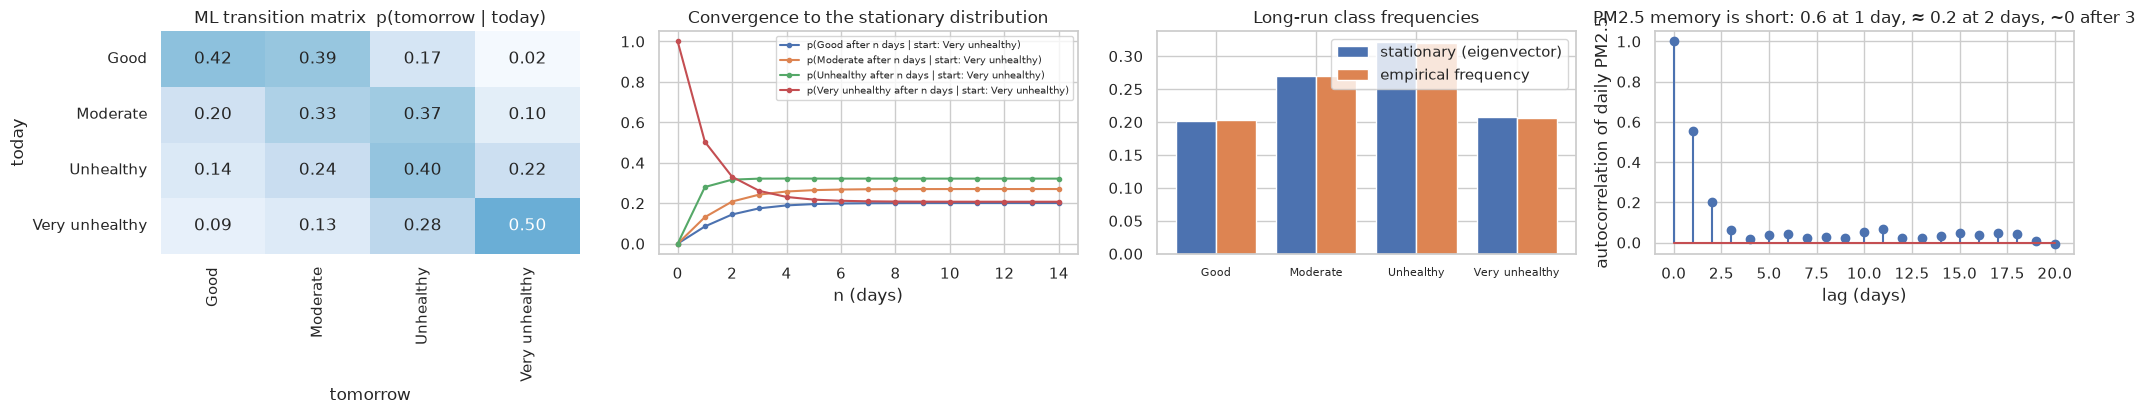

expected stay (days) in each class: {'Good': np.float64(1.71), 'Moderate': np.float64(1.49), 'Unhealthy': np.float64(1.67), 'Very unhealthy': np.float64(2.01)}
P(next day in the same class) = {'Good': np.float64(0.42), 'Moderate': np.float64(0.33), 'Unhealthy': np.float64(0.4), 'Very unhealthy': np.float64(0.5)}


In [3]:
counts = np.zeros((4, 4))
for o in train_seqs:
    for a, b in zip(o[:-1], o[1:]): counts[a, b] += 1
A_hat = counts / counts.sum(1, keepdims=True)                         # maximum likelihood estimate of the transition matrix

w, vv = np.linalg.eig(A_hat.T); stat = np.abs(np.real(vv[:, np.argmin(abs(w - 1))])); stat /= stat.sum()
freq = np.bincount(np.concatenate(train_seqs), minlength=4) / sum(map(len, train_seqs))
pm = pd.concat([g["pm25"] for g in runs]); ac = [pm.autocorr(l) for l in range(0, 21)]          # (approximate: ignores run boundaries)

fig, ax = plt.subplots(1, 4, figsize=(21, 4.3))
sns.heatmap(A_hat, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=S4, yticklabels=S4, cbar=False, ax=ax[0]); ax[0].set(title="ML transition matrix  p(tomorrow | today)", xlabel="tomorrow", ylabel="today")
for i in range(4): ax[1].plot([np.linalg.matrix_power(A_hat, k)[3, i] for k in range(15)], "o-", ms=3, label=f"p({S4[i]} after n days | start: Very unhealthy)")
ax[1].set(xlabel="n (days)", title="Convergence to the stationary distribution"); ax[1].legend(fontsize=7)
ax[2].bar(np.arange(4) - .2, stat, .4, label="stationary (eigenvector)"); ax[2].bar(np.arange(4) + .2, freq, .4, label="empirical frequency"); ax[2].set_xticks(range(4), S4, fontsize=8); ax[2].legend(); ax[2].set_title("Long-run class frequencies")
ax[3].stem(range(21), ac); ax[3].set(xlabel="lag (days)", ylabel="autocorrelation of daily PM2.5", title="PM2.5 memory is short: 0.6 at 1 day, ≈ 0.2 at 2 days, ~0 after 3"); plt.tight_layout(); plt.show()
print("expected stay (days) in each class:", dict(zip(S4, (1 / (1 - np.diag(A_hat))).round(2))))
print("P(next day in the same class) =", dict(zip(S4, np.diag(A_hat).round(2))))

### A2. Hidden Markov model
Latent states $z_t\in\{1..K\}$ follow a Markov chain; each emits an observation $x_t$ from $p(x_t|z_t)$:

$$p(X,Z|\theta)=p(z_1|\pi)\prod_{t=2}^T A_{z_{t-1}z_t}\prod_{t=1}^T p(x_t|z_t) .$$

Three classic problems: **evaluation** $p(X|\theta)$ (forward algorithm), **decoding** $\arg\max_Z p(Z|X)$ (Viterbi), **learning** $\theta$ (Baum–Welch = EM).

* **Forward** $\alpha_t(k)=p(x_{1:t},z_t=k)=\big[\sum_j\alpha_{t-1}(j)A_{jk}\big]p(x_t|k)$
* **Backward** $\beta_t(k)=p(x_{t+1:T}|z_t=k)=\sum_j A_{kj}p(x_{t+1}|j)\beta_{t+1}(j)$
* **Scaling.** $\alpha$ shrinks like $10^{-T}$ and underflows. Use $\hat\alpha_t=\alpha_t/p(x_{1:t})$ with scale factors $c_t=p(x_t|x_{1:t-1})$, so $\ln p(X)=\sum_t\ln c_t$.
* These recursions are the **sum-product algorithm** on the chain-structured factor graph; Viterbi is the **max-sum** version.
* **E-step**: $\gamma_t(k)=p(z_t=k|X)$, $\xi_t(j,k)=p(z_{t-1}=j,z_t=k|X)$. **M-step**: $\pi_k=\gamma_1(k)$, $A_{jk}=\sum_t\xi_t(j,k)/\sum_t\gamma_{t-1}(j)$, and emission parameters from $\gamma$-weighted statistics.

In [4]:
class HMM:
    """Hidden Markov model with discrete or 1-D Gaussian emissions (scaled forward-backward, Baum-Welch, Viterbi)."""

    def __init__(self, n_states, emission="discrete", n_symbols=None, n_iter=200, tol=1e-6, seed=0):
        self.K, self.emission, self.V, self.n_iter, self.tol, self.seed = n_states, emission, n_symbols, n_iter, tol, seed

    # ---------- parameters ----------
    def init_params(self, seqs, rng):
        K = self.K
        self.pi_ = rng.dirichlet(np.ones(K) * 5)
        self.A_ = rng.dirichlet(np.ones(K) * 5, size=K)
        if self.emission == "discrete":
            self.B_ = rng.dirichlet(np.ones(self.V), size=K)
        else:
            allx = np.concatenate(seqs); qs = np.quantile(allx, (np.arange(K) + .5) / K)
            self.mu_ = qs + rng.normal(0, allx.std() * .1, K); self.var_ = np.full(K, allx.var()) * rng.uniform(.5, 1.5, K)

    def log_emission(self, x):                       # (T, K) matrix of ln p(x_t | z_t = k)
        if self.emission == "discrete": return np.log(self.B_[:, x].T + 1e-300)
        return norm.logpdf(np.asarray(x)[:, None], self.mu_[None], np.sqrt(self.var_)[None])

    # ---------- inference ----------
    def forward_backward(self, x):
        K = self.K; logB = self.log_emission(x); T = len(logB); m = logB.max(1, keepdims=True); B = np.exp(logB - m)    # row-shifted for numerical safety
        alpha, c = np.zeros((T, K)), np.zeros(T)
        a = self.pi_ * B[0]; c[0] = a.sum(); alpha[0] = a / c[0]
        for t in range(1, T):
            a = (alpha[t - 1] @ self.A_) * B[t]; c[t] = a.sum(); alpha[t] = a / c[t]
        beta = np.ones((T, K))
        for t in range(T - 2, -1, -1):
            beta[t] = self.A_ @ (B[t + 1] * beta[t + 1]) / c[t + 1]
        loglik = np.log(c).sum() + m.sum()
        gamma = alpha * beta
        xi = (alpha[:-1, :, None] * self.A_[None] * (B[1:] * beta[1:])[:, None, :]) / c[1:, None, None]
        return alpha, beta, gamma, xi, loglik

    def score(self, x): return self.forward_backward(x)[-1]

    def viterbi(self, x):
        K = self.K; logA, logB = np.log(self.A_ + 1e-300), self.log_emission(x); T = len(logB)
        delta = np.zeros((T, K)); psi = np.zeros((T, K), int)
        delta[0] = np.log(self.pi_ + 1e-300) + logB[0]
        for t in range(1, T):
            cand = delta[t - 1][:, None] + logA; psi[t] = cand.argmax(0); delta[t] = cand.max(0) + logB[t]
        path = np.zeros(T, int); path[-1] = delta[-1].argmax()
        for t in range(T - 2, -1, -1): path[t] = psi[t + 1, path[t + 1]]
        return path, delta[-1].max()

    # ---------- learning (Baum-Welch) ----------
    def _fit_once(self, seqs, seed):
        rng = np.random.default_rng(seed); self.init_params(seqs, rng); hist = []
        for _ in range(self.n_iter):
            pi_acc, xi_acc, g_prev_acc = np.zeros(self.K), np.zeros((self.K, self.K)), np.zeros(self.K)
            if self.emission == "discrete": B_num = np.zeros((self.K, self.V))
            else: w_acc, wx_acc = np.zeros(self.K), np.zeros(self.K)
            ll = 0
            for x in seqs:
                _, _, g, xi, l = self.forward_backward(x); ll += l
                pi_acc += g[0]; xi_acc += xi.sum(0)
                if self.emission == "discrete":
                    for v in range(self.V): B_num[:, v] += g[np.asarray(x) == v].sum(0)
                else:
                    w_acc += g.sum(0); wx_acc += g.T @ np.asarray(x)
            hist.append(ll)
            self.pi_ = pi_acc / pi_acc.sum(); self.A_ = xi_acc / xi_acc.sum(1, keepdims=True)
            if self.emission == "discrete": self.B_ = (B_num + 1e-12) / (B_num + 1e-12).sum(1, keepdims=True)
            else:
                self.mu_ = wx_acc / w_acc
                self.var_ = np.maximum(sum(((np.asarray(x)[:, None] - self.mu_) ** 2 * self.forward_backward(x)[2]).sum(0) for x in seqs) / w_acc, 1e-6)
            if len(hist) > 1 and abs(hist[-1] - hist[-2]) < self.tol: break
        return hist[-1], hist

    def fit(self, seqs, n_restarts=5):
        seqs = [seqs] if np.ndim(seqs[0]) == 0 else seqs
        best = None
        for r in range(n_restarts):
            ll, hist = self._fit_once(seqs, self.seed + r)
            if best is None or ll > best[0]: best = (ll, hist, self.get_params())
        self.set_params(best[2]); self.loglik_, self.history_ = best[0], best[1]
        self.n_obs_ = sum(len(x) for x in seqs); return self

    def get_params(self): return {k: getattr(self, k).copy() for k in ["pi_", "A_", "B_", "mu_", "var_"] if hasattr(self, k)}
    def set_params(self, d): [setattr(self, k, v.copy()) for k, v in d.items()]
    def n_params(self): return (self.K - 1) + self.K * (self.K - 1) + (self.K * (self.V - 1) if self.emission == "discrete" else 2 * self.K)
    def bic(self): return -2 * self.loglik_ + self.n_params() * np.log(self.n_obs_)

    # ---------- prediction ----------
    def predictive(self, x):
        """p(x_{t+1} | x_{1:t}) for every t (discrete: (T,V) probabilities; gaussian: mixture weights (T,K))."""
        alpha = self.forward_backward(x)[0]; next_state = alpha @ self.A_
        return next_state @ self.B_ if self.emission == "discrete" else next_state

    def sample(self, T, seed=0):
        r = np.random.default_rng(seed); z = np.zeros(T, int); z[0] = r.choice(self.K, p=self.pi_)
        for t in range(1, T): z[t] = r.choice(self.K, p=self.A_[z[t - 1]])
        if self.emission == "discrete": x = np.array([r.choice(self.V, p=self.B_[k]) for k in z])
        else: x = r.normal(self.mu_[z], np.sqrt(self.var_[z]))
        return x, z

def set_hmm(model, pi, A, B=None, mu=None, var=None):
    model.pi_, model.A_ = np.array(pi, float), np.array(A, float)
    if B is not None: model.B_ = np.array(B, float)
    if mu is not None: model.mu_, model.var_ = np.array(mu, float), np.array(var, float)
    return model

### A2b. Extension — HMM with autoregressive emissions (Markov-switching AR)
A plain Gaussian HMM treats observations as independent *given the state*. For a smooth series such as hourly PM2.5 that throws away the best predictor of the next value — the current value. The remedy is to let the emission depend on the previous observation:

$$x_t\mid x_{t-1},z_t=k\ \sim\ \mathcal N\big(a_k+b_k\,x_{t-1},\ \sigma_k^2\big).$$

Every regime is now a small AR(1) model with its own level, persistence $b_k$ and noise. Nothing else changes: the same scaled forward–backward recursions, Baum–Welch and Viterbi apply. Only the emission term (conditioning on the first observation of each sequence)
and its M-step (a state-weighted least-squares fit of $a_k,b_k$ and weighted residual variance) are replaced — the classical *Markov-switching autoregression* (Hamilton, 1989). We implement it as a subclass of `HMM`.

In [5]:
class MSAR(HMM):
    """Markov-switching AR(1):  x_t | x_{t-1}, z_t=k ~ N(a_k + b_k x_{t-1}, s_k^2).  Reuses HMM.forward_backward / viterbi (T-1 emission rows per sequence)."""

    def __init__(self, n_states, n_iter=100, tol=1e-6, seed=0): super().__init__(n_states, "msar", None, n_iter, tol, seed)

    def init_params(self, seqs, rng):
        K = self.K; self.pi_ = np.full(K, 1 / K); self.A_ = np.full((K, K), .2 / K) + .8 * np.eye(K)          # sticky start
        qs = np.quantile(np.concatenate(seqs), (np.arange(K) + .5) / K)
        self.b_ = .9 + rng.normal(0, .03, K); self.a_ = (1 - self.b_) * qs; self.var_ = np.full(K, .1) * rng.uniform(.5, 1.5, K)

    def log_emission(self, x):                                # (T-1, K): ln p(x_t | x_{t-1}, z_t = k) for t = 2..T
        x = np.asarray(x); return norm.logpdf(x[1:, None], self.a_[None] + self.b_[None] * x[:-1, None], np.sqrt(self.var_)[None])

    def score(self, x): return 0.0 if len(x) < 2 else super().score(x)

    def _fit_once(self, seqs, seed):
        rng = np.random.default_rng(seed); self.init_params(seqs, rng); K = self.K; hist = []
        for _ in range(self.n_iter):
            pi_acc, xi_acc, S, gs, ll = np.zeros(K), np.zeros((K, K)), np.zeros((5, K)), [], 0.0
            for x in seqs:
                x = np.asarray(x); _, _, g, xi, l = self.forward_backward(x); ll += l; gs.append(g); pi_acc += g[0]; xi_acc += xi.sum(0)
                xp, xc = x[:-1, None], x[1:, None]                                   # regressor / response, weighted by the state posteriors
                S += np.stack([g.sum(0), (g * xp).sum(0), (g * xc).sum(0), (g * xp * xp).sum(0), (g * xp * xc).sum(0)])
            hist.append(ll)
            self.pi_ = pi_acc / pi_acc.sum(); self.A_ = xi_acc / xi_acc.sum(1, keepdims=True)
            n_, sx, sy, sxx, sxy = S                                                 # weighted least squares, one regression per state
            self.b_ = (n_ * sxy - sx * sy) / (n_ * sxx - sx ** 2); self.a_ = (sy - self.b_ * sx) / n_
            self.var_ = np.maximum(sum((g * (np.asarray(x)[1:, None] - self.a_ - self.b_ * np.asarray(x)[:-1, None]) ** 2).sum(0) for g, x in zip(gs, seqs)) / n_, 1e-4)
            if len(hist) > 1 and abs(hist[-1] - hist[-2]) < self.tol: break
        return hist[-1], hist

    def fit(self, seqs, n_restarts=5):
        super().fit(seqs, n_restarts); self.n_obs_ = sum(len(x) - 1 for x in ([seqs] if np.ndim(seqs[0]) == 0 else seqs)); return self

    def get_params(self): return {k: getattr(self, k).copy() for k in ["pi_", "A_", "a_", "b_", "var_"] if hasattr(self, k)}
    def n_params(self): return (self.K - 1) + self.K * (self.K - 1) + 3 * self.K

    def forecast_samples(self, alpha_t, x_t, h, n_draws=300, seed=0):
        """Monte-Carlo draws of x_{t+h} for many forecast origins at once. alpha_t: (n, K) filtered state probabilities, x_t: (n,) values at the origins."""
        rng = np.random.default_rng(seed); n = len(x_t); cumA = self.A_.cumsum(1)
        z = (rng.random((n, n_draws, 1)) > np.asarray(alpha_t).cumsum(1)[:, None, :]).sum(2).clip(max=self.K - 1); x = np.repeat(np.asarray(x_t, float)[:, None], n_draws, 1)
        for _ in range(h):
            z = (rng.random((n, n_draws, 1)) > cumA[z]).sum(2).clip(max=self.K - 1)
            x = self.a_[z] + self.b_[z] * x + np.sqrt(self.var_[z]) * rng.normal(size=(n, n_draws))
        return x

# does Baum-Welch recover the parameters of a simulated Markov-switching AR?
rng = np.random.default_rng(3); tru = dict(a=[.3, .0], b=[.5, .95], s=[.6, .15], A=np.array([[.9, .1], [.05, .95]]))
def sim(T):
    z = np.zeros(T, int); x = np.zeros(T)
    for t in range(1, T): z[t] = rng.choice(2, p=tru["A"][z[t - 1]]); x[t] = tru["a"][z[t]] + tru["b"][z[t]] * x[t - 1] + tru["s"][z[t]] * rng.normal()
    return x
chk = MSAR(2, n_iter=200, tol=1e-5).fit([sim(1500) for _ in range(4)], n_restarts=4); o_ = np.argsort(chk.b_)
print(pd.DataFrame({"a (true)": tru["a"], "a (fit)": chk.a_[o_], "b (true)": tru["b"], "b (fit)": chk.b_[o_], "σ (true)": tru["s"], "σ (fit)": np.sqrt(chk.var_[o_])}, index=["regime 1", "regime 2"]).round(3).to_string())
print("transition matrix, true:", tru["A"].round(2).tolist(), "  fitted:", chk.A_[np.ix_(o_, o_)].round(2).tolist())
assert np.all(np.diff(chk.history_) > -1e-6), "EM must not decrease the likelihood"

          a (true)  a (fit)  b (true)  b (fit)  σ (true)  σ (fit)
regime 1       0.3    0.293      0.50    0.517      0.60    0.606
regime 2       0.0    0.001      0.95    0.945      0.15    0.150
transition matrix, true: [[0.9, 0.1], [0.05, 0.95]]   fitted: [[0.91, 0.09], [0.05, 0.95]]


### A3. Validating the algorithms
1. **Forward algorithm vs. brute force.** For a short sequence enumerate all $K^T$ state paths and sum the joint probability.
2. **Viterbi vs. brute force.** The best path must equal the arg-max over all paths.
3. **Why scaling matters.** The un-scaled forward variable underflows to 0 for long sequences; the scaled one doesn't.

likelihood   brute force = 0.0011220940   forward algorithm = 0.0011220940
best path    brute force = (1, 0, 0, 0, 1, 1)   Viterbi = (1, 0, 0, 0, 1, 1)   (log-prob -8.788939 vs -8.788939)
posterior p(z_3=0 | X): brute force = 0.895480   forward-backward = 0.895480


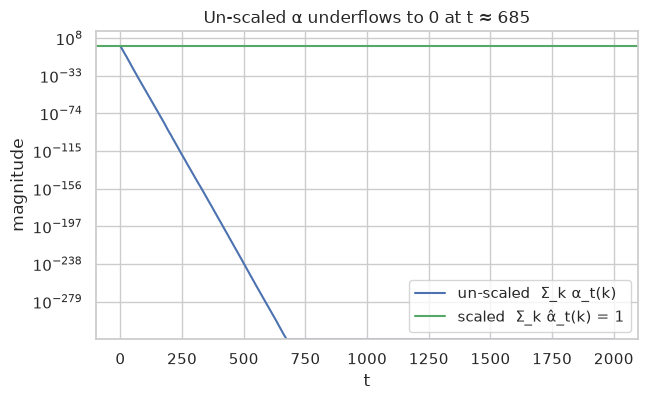

scaled log-likelihood of the 2000-step sequence: -2189.31


In [6]:
toy = set_hmm(HMM(2, "discrete", 3), pi=[.6, .4], A=[[.7, .3], [.4, .6]], B=[[.1, .4, .5], [.6, .3, .1]])
obs = np.array([0, 1, 2, 2, 0, 1])

# brute force enumeration of all 2^6 paths
joint = {}
for path in product(range(2), repeat=len(obs)):
    p = toy.pi_[path[0]] * toy.B_[path[0], obs[0]]
    for t in range(1, len(obs)): p *= toy.A_[path[t - 1], path[t]] * toy.B_[path[t], obs[t]]
    joint[path] = p
bf_lik = sum(joint.values()); bf_path = max(joint, key=joint.get)
vpath, vlog = toy.viterbi(obs)
print(f"likelihood   brute force = {bf_lik:.10f}   forward algorithm = {np.exp(toy.score(obs)):.10f}")
print(f"best path    brute force = {bf_path}   Viterbi = {tuple(int(v) for v in vpath)}   (log-prob {np.log(joint[bf_path]):.6f} vs {vlog:.6f})")
_, _, gamma, xi, _ = toy.forward_backward(obs)
bf_gamma0 = sum(p for path, p in joint.items() if path[2] == 0) / bf_lik
print(f"posterior p(z_3=0 | X): brute force = {bf_gamma0:.6f}   forward-backward = {gamma[2, 0]:.6f}")

# underflow of the un-scaled forward recursion
long_obs, _ = toy.sample(2000, seed=1); a = toy.pi_ * toy.B_[:, long_obs[0]]; mags = [a.sum()]
for x in long_obs[1:]: a = (a @ toy.A_) * toy.B_[:, x]; mags.append(a.sum())
mags = np.array(mags); first_zero = int(np.argmax(mags == 0))
plt.figure(figsize=(7, 4)); plt.semilogy(np.maximum(mags, 1e-320), label="un-scaled  Σ_k α_t(k)")
plt.axhline(1, c="g", label="scaled  Σ_k α̂_t(k) = 1"); plt.xlabel("t"); plt.ylabel("magnitude"); plt.legend(); plt.title(f"Un-scaled α underflows to 0 at t ≈ {first_zero}"); plt.show()
print(f"scaled log-likelihood of the 2000-step sequence: {toy.score(long_obs):.2f}")

## Practice 1 — Implement an HMM to predict sequential data

### Problem 1: hidden pollution regimes from the daily air-quality class (discrete HMM)
Tasks: (i) **learn** the HMM from the observed classes only (Baum–Welch) and choose the number of hidden states, (ii) **interpret** the hidden states using weather that was never used for fitting,
(iii) **decode** the regime sequence (Viterbi vs posterior), (iv) **predict** tomorrow's class and several days ahead, (v) compare with baselines on the 2014 test year.

#### (i) Learn the model with Baum–Welch (EM) and choose the number of hidden states

,params,train_ll_per_day,test_ll_per_day,BIC
K,,,,
1,3,-1.368,-1.360,3796.428
2,9,-1.291,-1.280,3627.922
3,17,-1.254,-1.246,3583.002
4,27,-1.237,-1.231,3610.423
5,39,-1.224,-1.228,3661.043


BIC selects K = 3


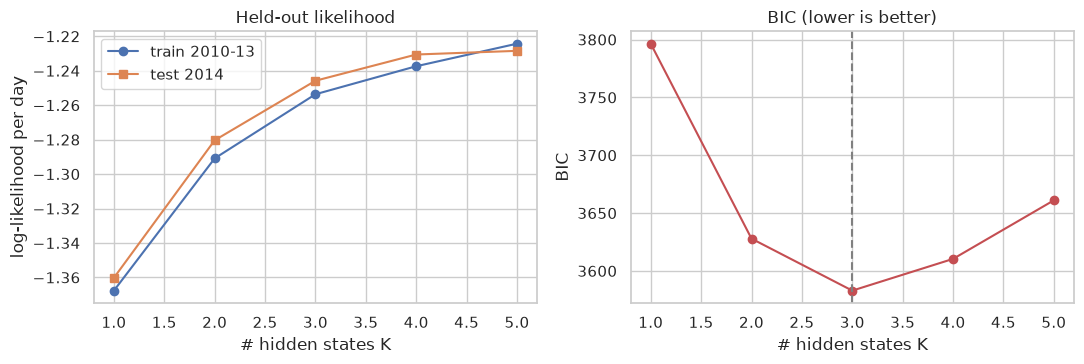

In [7]:
def test_loglik(m, discrete=True):
    """log p(2014 days | earlier days of the same run) under a model trained on ≤ 2013: ll(full run) − ll(training prefix)."""
    tot, nobs = 0.0, 0
    for o, k in zip(obs_runs if discrete else ly_runs, n_train):
        if len(o) == k: continue
        tot += m.score(o) - (m.score(o[:k]) if k > 0 else 0.0); nobs += len(o) - k
    return tot, nobs

rows, models = [], {}
for K in range(1, 6):
    m = HMM(K, "discrete", 4, seed=0).fit(train_seqs, n_restarts=10); models[K] = m
    tl, tn = test_loglik(m); rows.append(dict(K=K, params=m.n_params(), train_ll_per_day=m.loglik_ / m.n_obs_, test_ll_per_day=tl / tn, BIC=m.bic()))
sel = pd.DataFrame(rows).set_index("K"); display(sel.round(3))
K_best = int(sel["BIC"].idxmin()); print("BIC selects K =", K_best)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(sel.index, sel["train_ll_per_day"], "o-", label="train 2010-13"); ax[0].plot(sel.index, sel["test_ll_per_day"], "s-", label="test 2014"); ax[0].legend(); ax[0].set(xlabel="# hidden states K", ylabel="log-likelihood per day", title="Held-out likelihood")
ax[1].plot(sel.index, sel["BIC"], "o-r"); ax[1].axvline(K_best, ls="--", c="gray"); ax[1].set(xlabel="# hidden states K", ylabel="BIC", title="BIC (lower is better)"); plt.tight_layout(); plt.show()

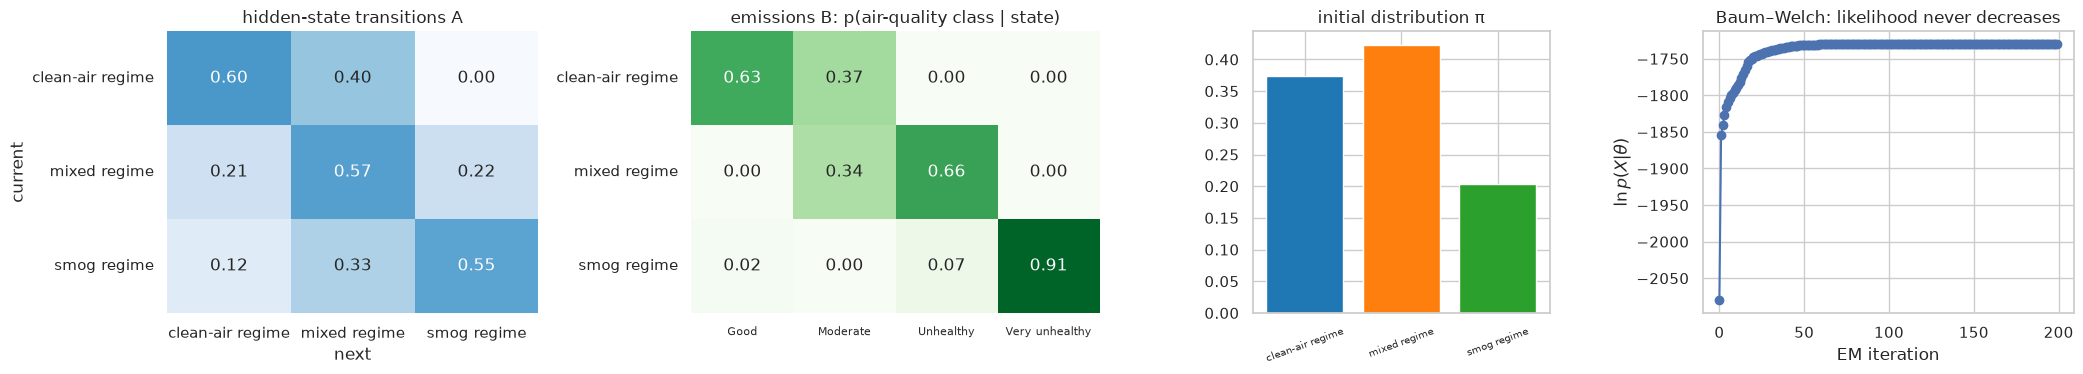

expected stay (days) in each hidden state = 1/(1−A_ii): {'clean-air regime': np.float64(2.5), 'mixed regime': np.float64(2.3), 'smog regime': np.float64(2.2)}


In [8]:
model = models[K_best]
# order the hidden states from clean to smoggy by their expected observed class
order = np.argsort(model.B_ @ np.arange(4)); model.pi_, model.A_, model.B_ = model.pi_[order], model.A_[np.ix_(order, order)], model.B_[order]
STATE = {3: ["clean-air regime", "mixed regime", "smog regime"], 2: ["clean-air regime", "smog regime"], 4: ["clean", "mild", "polluted", "smog"], 5: ["s1", "s2", "s3", "s4", "s5"], 1: ["single"]}[K_best]

fig, ax = plt.subplots(1, 4, figsize=(21, 3.9), gridspec_kw={"width_ratios": [1, 1.1, .8, 1]})
sns.heatmap(model.A_, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=STATE, yticklabels=STATE, cbar=False, ax=ax[0]); ax[0].set(title="hidden-state transitions A", xlabel="next", ylabel="current")
sns.heatmap(model.B_, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, xticklabels=S4, yticklabels=STATE, cbar=False, ax=ax[1]); ax[1].set(title="emissions B: p(air-quality class | state)"); ax[1].tick_params(axis="x", labelsize=8)
ax[2].bar(STATE, model.pi_, color=PAL[:K_best]); ax[2].set_title("initial distribution π"); ax[2].tick_params(axis="x", labelrotation=20, labelsize=7)
ax[3].plot(model.history_, "o-"); ax[3].set(xlabel="EM iteration", ylabel=r"$\ln p(X|\theta)$", title="Baum–Welch: likelihood never decreases")
plt.tight_layout(); plt.show()
assert np.all(np.diff(model.history_) > -1e-6), "EM must not decrease the likelihood"
print("expected stay (days) in each hidden state = 1/(1−A_ii):", dict(zip(STATE, (1 / (1 - np.diag(model.A_))).round(1))))

#### (ii) What are the hidden states? Validate them with weather the model never saw
Decode every day with Viterbi (using the full runs), then compare average weather per decoded state. If the HMM has found real air-mass regimes, the weather should differ systematically.

,days,PM25,wind,calm_share,temp,dew,pres
clean-air regime,636,36.10,93.02,0.15,11.87,-2.49,1017.77
mixed regime,762,94.17,44.85,0.23,14.23,4.74,1014.99
smog regime,355,220.22,31.16,0.29,9.51,3.02,1017.10


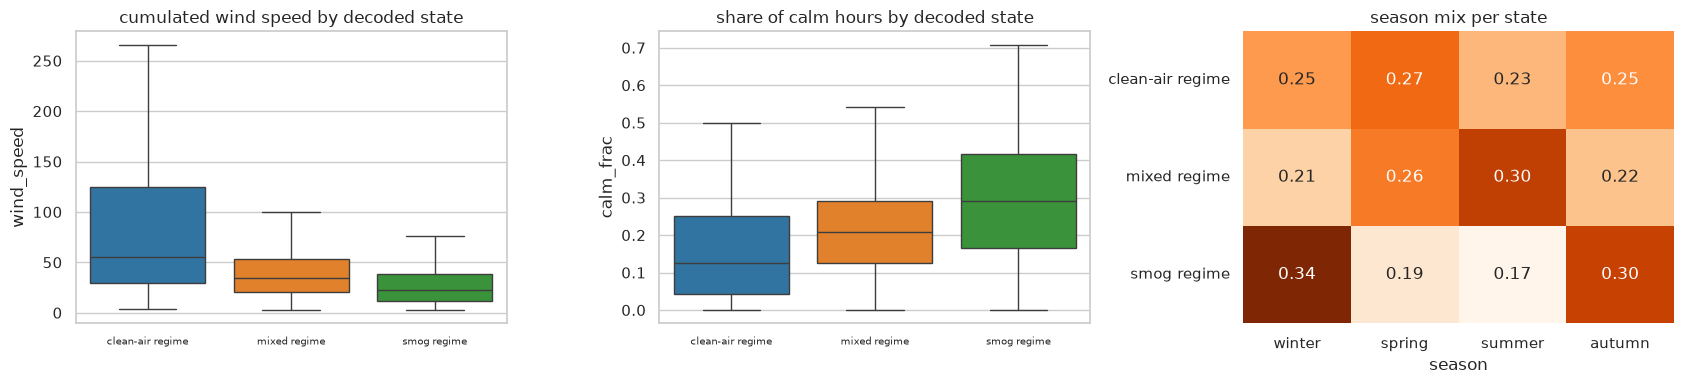

→ the smog regime coincides with weak wind and many calm hours — stagnation that the HMM inferred purely from the sequence of air-quality classes.


In [9]:
dec = [model.viterbi(o)[0] for o in obs_runs]
alld = pd.concat([g.assign(state=STATE_ARR) for g, STATE_ARR in zip(runs, dec)])
prof = alld.groupby("state").agg(days=("pm25", "size"), PM25=("pm25", "mean"), wind=("wind_speed", "mean"), calm_share=("calm_frac", "mean"), temp=("temp", "mean"), dew=("dew", "mean"), pres=("pres", "mean")).round(2)
prof.index = STATE; display(prof)

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for a_, col, ttl in [(ax[0], "wind_speed", "cumulated wind speed"), (ax[1], "calm_frac", "share of calm hours")]:
    sns.boxplot(data=alld, x="state", y=col, hue="state", legend=False, palette=PAL[:K_best], showfliers=False, ax=a_); a_.set_xticks(range(K_best), STATE, fontsize=7); a_.set(title=f"{ttl} by decoded state", xlabel="")
sns.heatmap(pd.crosstab(alld["state"], alld["season"], normalize="index")[["winter", "spring", "summer", "autumn"]].set_axis(STATE, axis=0), annot=True, fmt=".2f", cmap="Oranges", cbar=False, ax=ax[2]); ax[2].set_title("season mix per state"); ax[2].set_ylabel("")
plt.tight_layout(); plt.show()
print("→ the smog regime coincides with weak wind and many calm hours — stagnation that the HMM inferred purely from the sequence of air-quality classes.")

#### (iii) Decode the regime sequence: Viterbi (single best path) vs. posterior marginals

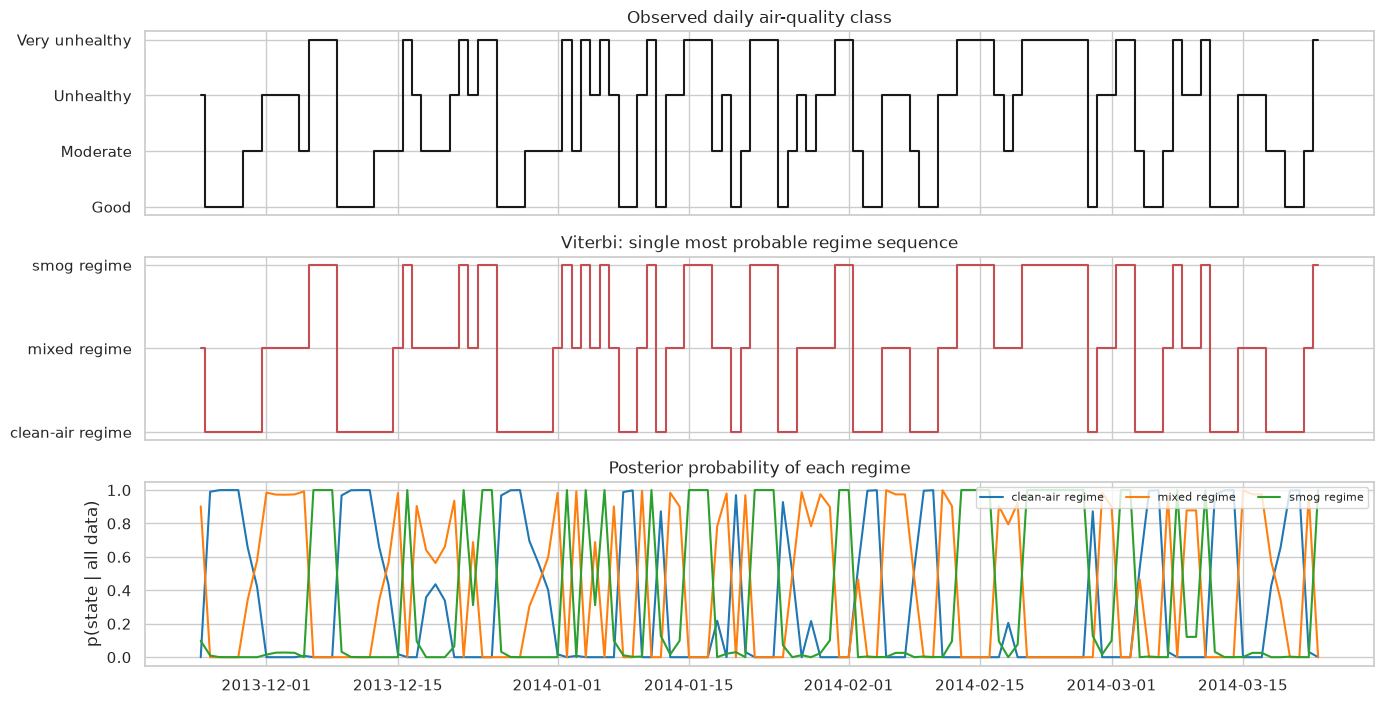

Viterbi path and per-day posterior arg-max agree on 96.5% of the days of this run; they can differ because Viterbi maximises the joint sequence probability, not each day separately.


In [10]:
big = int(np.argmax([len(o) for o in obs_runs])); o = obs_runs[big]; dts = runs[big].index                 # the longest run (733 days)
path, _ = model.viterbi(o); post = model.forward_backward(o)[2]
s0 = 330; w = slice(s0, s0 + 120)
fig, ax = plt.subplots(3, 1, figsize=(14, 7.2), sharex=True)
ax[0].step(dts[w], o[w], where="mid", c="k"); ax[0].set_yticks(range(4), S4); ax[0].set_title("Observed daily air-quality class")
ax[1].step(dts[w], path[w], where="mid", c="C3"); ax[1].set_yticks(range(K_best), STATE); ax[1].set_title("Viterbi: single most probable regime sequence")
for k in range(K_best): ax[2].plot(dts[w], post[w, k], label=STATE[k], c=PAL[k])
ax[2].set(ylabel="p(state | all data)", title="Posterior probability of each regime"); ax[2].legend(ncol=K_best, fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()
agree = np.mean(path == post.argmax(1)); print(f"Viterbi path and per-day posterior arg-max agree on {agree:.1%} of the days of this run; they can differ because Viterbi maximises the joint sequence probability, not each day separately.")

#### (iv) Predict tomorrow — and several days ahead
Given the history $x_{1:t}$ the HMM predicts $p(x_{t+h}|x_{1:t})=\sum_j\Big[\sum_i\hat\alpha_t(i)(A^h)_{ij}\Big]B_{j,x_{t+h}}$.
Baselines: (a) **climatology** (class frequencies of the training years); (b) a first-order **Markov chain on the observed classes**; (c) **persistence** (repeat today's class, a point forecast).
Evaluation covers every 2014 day, filtering through the earlier days of its run; parameters come from 2010–2013 only.

,accuracy,log_loss
climatology,0.3425,1.3602
Markov on observations,0.4438,1.2272
HMM (K=3),0.4411,1.2458
persistence (today's class),0.4411,NaN


365 test forecasts (tomorrow's class, 2014)


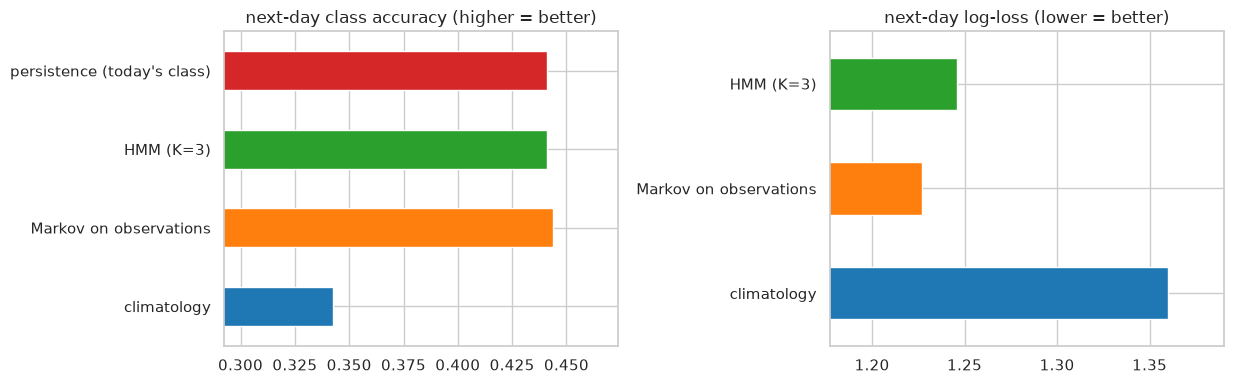

In [11]:
def eval_set(h):
    """(alpha_t for HMM, class at t, class at t+h) for all origins t with target day in 2014."""
    A_, Y_, T_ = [], [], []
    for o, g in zip(obs_runs, runs):
        if len(o) <= h: continue
        tgt_year = g.index.year.values[h:]; sel = np.where(tgt_year == 2014)[0]
        if len(sel) == 0: continue
        alpha = model.forward_backward(o)[0]; A_.append(alpha[sel]); Y_.append(o[sel]); T_.append(o[sel + h])
    return np.vstack(A_), np.concatenate(Y_), np.concatenate(T_)

Tm = A_hat + 1e-3; Tm /= Tm.sum(1, keepdims=True)                      # Markov chain on observations (tiny smoothing)
def forecasts(h):
    al, now, tgt = eval_set(h)
    return {"climatology": np.tile(freq, (len(tgt), 1)), "Markov on observations": np.linalg.matrix_power(Tm, h)[now],
            f"HMM (K={K_best})": al @ np.linalg.matrix_power(model.A_, h) @ model.B_}, now, tgt
def metrics(P, tgt): return dict(accuracy=np.mean(P.argmax(1) == tgt), log_loss=-np.mean(np.log(P[np.arange(len(tgt)), tgt] + 1e-12)))

P1, now1, tgt1 = forecasts(1)
res = pd.DataFrame({k: metrics(P, tgt1) for k, P in P1.items()}).T
res.loc["persistence (today's class)"] = [np.mean(now1 == tgt1), np.nan]
display(res.round(4)); print(f"{len(tgt1)} test forecasts (tomorrow's class, 2014)")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
res["accuracy"].plot.barh(ax=ax[0], color=PAL[:4]); ax[0].set(xlim=(res["accuracy"].min() - .05, res["accuracy"].max() + .03), title="next-day class accuracy (higher = better)")
res["log_loss"].dropna().plot.barh(ax=ax[1], color=PAL[:3]); ax[1].set(xlim=(res["log_loss"].min() - .05, res["log_loss"].max() + .03), title="next-day log-loss (lower = better)")
plt.tight_layout(); plt.show()

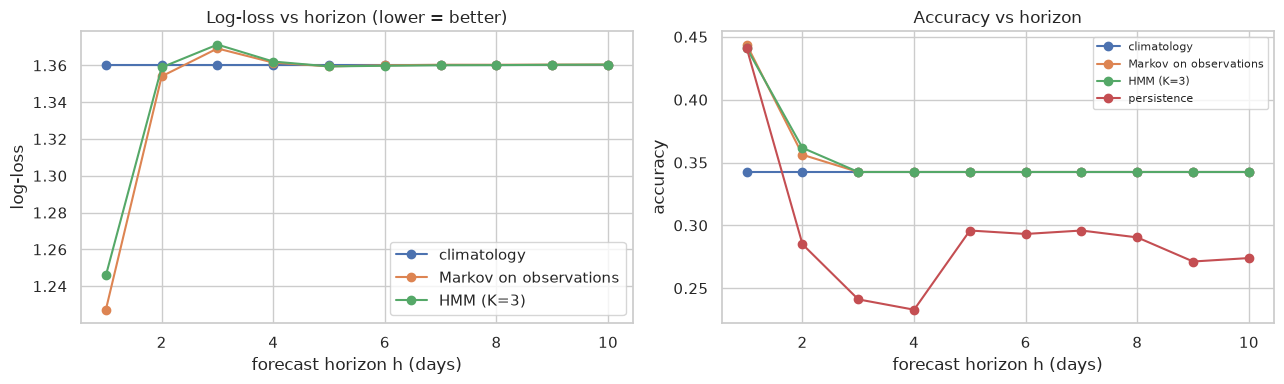

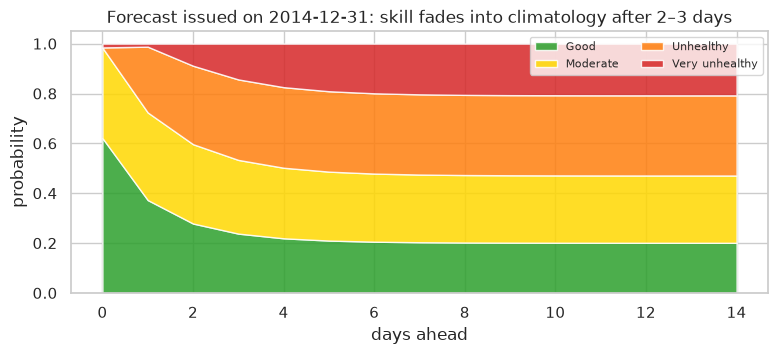

In [12]:
# skill versus forecast horizon: the HMM forecast relaxes to the climatology as memory fades
H = range(1, 11); curves = {k: [] for k in ["climatology", "Markov on observations", f"HMM (K={K_best})"]}; acc = {k: [] for k in list(curves) + ["persistence"]}
for h in H:
    Pf, now, tgt = forecasts(h)
    for k, P in Pf.items(): m_ = metrics(P, tgt); curves[k].append(m_["log_loss"]); acc[k].append(m_["accuracy"])
    acc["persistence"].append(np.mean(now == tgt))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, c in curves.items(): ax[0].plot(H, c, "o-", label=k)
ax[0].set(xlabel="forecast horizon h (days)", ylabel="log-loss", title="Log-loss vs horizon (lower = better)"); ax[0].legend()
for k, c in acc.items(): ax[1].plot(H, c, "o-", label=k)
ax[1].set(xlabel="forecast horizon h (days)", ylabel="accuracy", title="Accuracy vs horizon"); ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

al_T = model.forward_backward(obs_runs[big])[0][-1]; fc = np.array([al_T @ np.linalg.matrix_power(model.A_, h) @ model.B_ for h in range(0, 15)])
plt.figure(figsize=(9, 3.4)); plt.stackplot(range(0, 15), fc.T, labels=S4, colors=["tab:green", "gold", "tab:orange", "tab:red"], alpha=.85); plt.xlabel("days ahead"); plt.ylabel("probability"); plt.legend(loc="upper right", fontsize=8, ncol=2)
plt.title(f"Forecast issued on {runs[big].index[-1].date()}: skill fades into climatology after 2–3 days"); plt.show()

**Reading the results.** For tomorrow's class every sequence model beats climatology (accuracy 0.44 vs 0.34), because pollution has a day or two of memory. The HMM and the plain Markov chain on the observed classes are practically tied (the Markov chain is even slightly better in log-loss):
when today's observed class is almost as informative as the hidden regime, the hidden layer buys little for a one-day forecast. Beyond 2–3 days **no model beats climatology** — daily weather-driven pollution is simply not predictable from past pollution alone (Week 2 showed that *weather* explains much more).
The HMM's value here is the **interpretation** (smog regime ↔ weak wind, many calm hours) and its principled handling of uncertainty and missing days, not a forecasting gain.

### Problem 2: regime detection in the continuous ln PM2.5 (Gaussian-emission HMM)
Now the observation is the number itself, $x_t=\ln(\text{PM2.5})$, and each hidden state emits a Gaussian $\mathcal N(\mu_k,\sigma_k^2)$.

In [13]:
rows, gms = [], {}
for K in range(1, 6):
    g = HMM(K, "gaussian", seed=0).fit(train_ly, n_restarts=8); gms[K] = g; tl, tn = test_loglik(g, discrete=False)
    rows.append(dict(K=K, train_ll_per_day=g.loglik_ / g.n_obs_, test_ll_per_day=tl / tn, BIC=g.bic()))
selg = pd.DataFrame(rows).set_index("K"); display(selg.round(3)); Kg = int(selg["BIC"].idxmin()); print("BIC selects K =", Kg)

g = gms[Kg]; o_ = np.argsort(g.mu_); g.pi_, g.A_, g.mu_, g.var_ = g.pi_[o_], g.A_[np.ix_(o_, o_)], g.mu_[o_], g.var_[o_]
GN = {2: ["clean regime", "polluted regime"], 3: ["clean regime", "moderate regime", "smog regime"], 4: ["clean", "moderate", "polluted", "smog"], 5: list("12345"), 1: ["one"]}[Kg]
print(pd.DataFrame({"median PM2.5 (µg/m³)": np.exp(g.mu_), "sd of ln PM2.5": np.sqrt(g.var_), "P(stay)": np.diag(g.A_), "expected stay (days)": 1 / (1 - np.diag(g.A_))}, index=GN).round(2).T.to_string())

,train_ll_per_day,test_ll_per_day,BIC
K,,,
1,-1.226,-1.263,3397.494
2,-1.129,-1.192,3165.612
3,-1.063,-1.143,3034.971
4,-1.032,-1.101,3014.852
5,-1.012,-1.078,3039.541


BIC selects K = 4
                      clean  moderate  polluted    smog
median PM2.5 (µg/m³)  23.62     67.19    135.60  247.20
sd of ln PM2.5         0.43      0.34      0.27    0.30
P(stay)                0.50      0.51      0.48    0.56
expected stay (days)   2.01      2.05      1.92    2.29


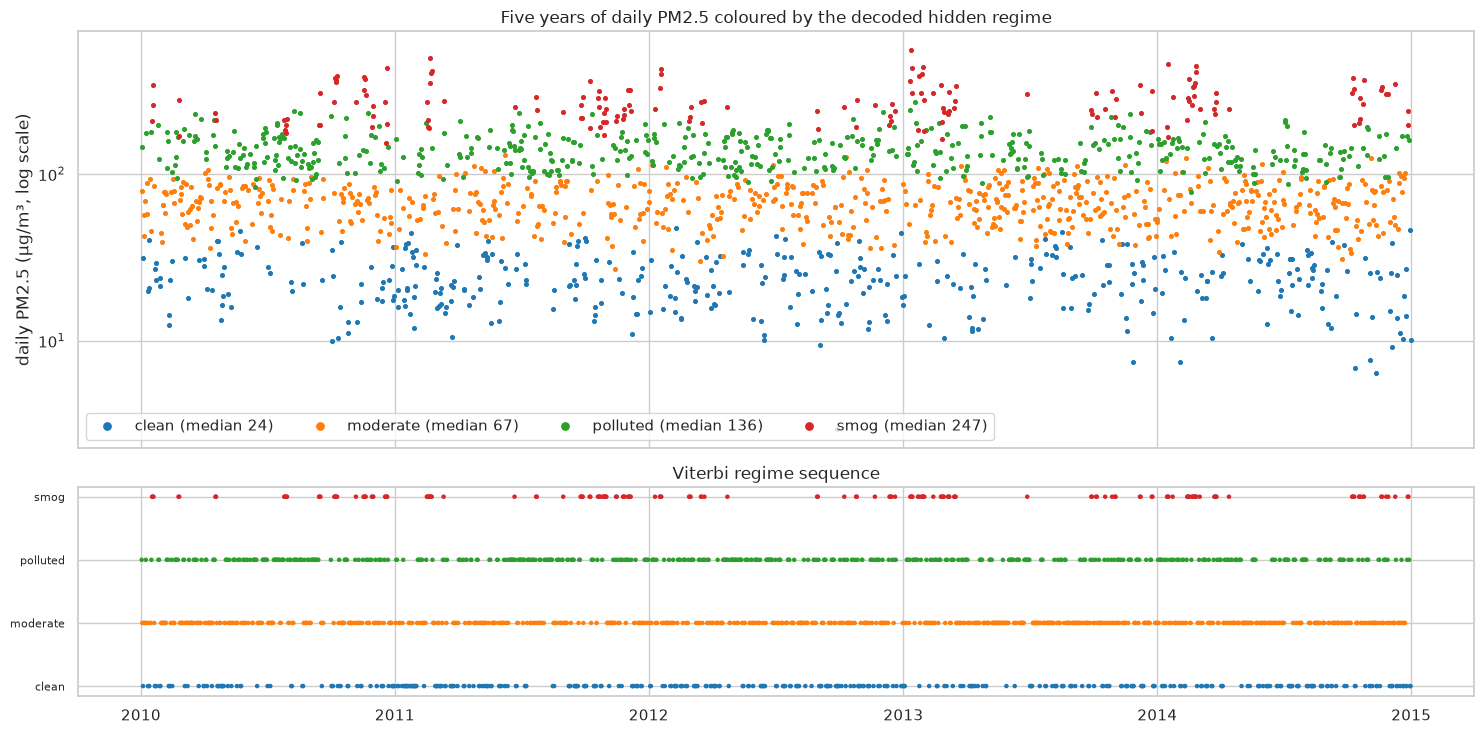

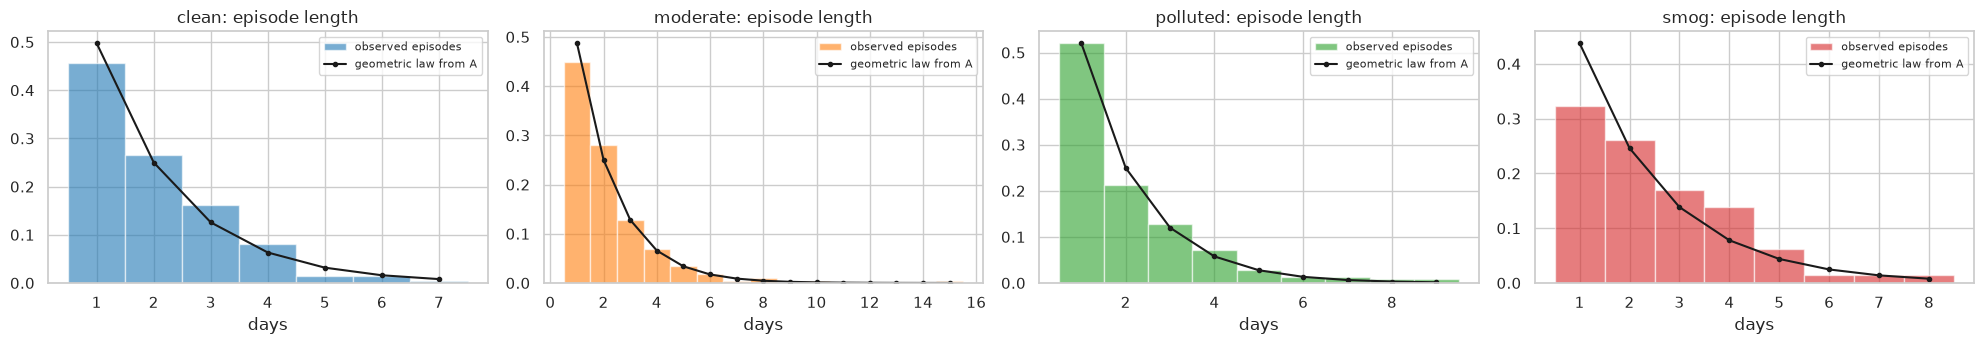

In [14]:
dec_g = [g.viterbi(y)[0] for y in ly_runs]; alld_g = pd.concat([r.assign(state=s) for r, s in zip(runs, dec_g)]).sort_index()
fig, ax = plt.subplots(2, 1, figsize=(15, 7.5), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)
for k in range(Kg): m_ = alld_g["state"] == k; ax[0].scatter(alld_g.index[m_], alld_g["pm25"][m_], s=7, color=PAL[k], label=f"{GN[k]} (median {np.exp(g.mu_[k]):.0f})")
ax[0].set_yscale("log"); ax[0].set(ylabel="daily PM2.5 (µg/m³, log scale)", title="Five years of daily PM2.5 coloured by the decoded hidden regime"); ax[0].legend(markerscale=2, ncol=Kg)
ax[1].scatter(alld_g.index, alld_g["state"], c=[PAL[k] for k in alld_g["state"]], s=5); ax[1].set_yticks(range(Kg), GN, fontsize=8); ax[1].set_title("Viterbi regime sequence"); plt.tight_layout(); plt.show()

# does the fitted HMM generate realistic episode lengths?  compare observed run lengths of regimes with the geometric law implied by A
fig, ax = plt.subplots(1, Kg, figsize=(5 * Kg, 3.6))
for k in range(Kg):
    lens = []
    for s in dec_g:
        cur = 0
        for z in s:
            if z == k: cur += 1
            elif cur: lens.append(cur); cur = 0
        if cur: lens.append(cur)
    mx = max(lens); b = np.arange(1, min(mx, 25) + 1); stay = g.A_[k, k]
    ax[k if Kg > 1 else 0].hist(lens, bins=np.arange(.5, min(mx, 25) + 1.5), density=True, alpha=.6, color=PAL[k], label="observed episodes"); ax[k if Kg > 1 else 0].plot(b, stay ** (b - 1) * (1 - stay), "ko-", ms=3, label="geometric law from A")
    ax[k if Kg > 1 else 0].set(title=f"{GN[k]}: episode length", xlabel="days"); ax[k if Kg > 1 else 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

#### One-step-ahead forecast of PM2.5 and comparison with simple baselines
The HMM forecast for tomorrow is a **mixture of Gaussians** (one per hidden state, weighted by the predicted state probabilities). Baselines: climatology (a single Gaussian fitted to 2010–2013) and an **AR(1) model** on ln PM2.5
($x_{t+1}=a+bx_t+\varepsilon$), the standard linear time-series competitor. Metrics on all 2014 days: MAE of the point forecast, mean log predictive density, and coverage of the 80 % interval.

AR(1) on ln PM2.5: x_(t+1) = 2.16 + 0.50·x_t, residual sd = 0.71   |   climatology: mean 4.29, sd 0.82


,MAE of median forecast (µg/m³),mean log predictive density
climatology,56.532,-1.263
persistence (yesterday),52.752,NaN
AR(1) on ln PM2.5,48.783,-1.138
Gaussian HMM (K=4),49.386,-1.101


80% interval coverage of the HMM mixture: 77.5% of 365 days (target 80%)


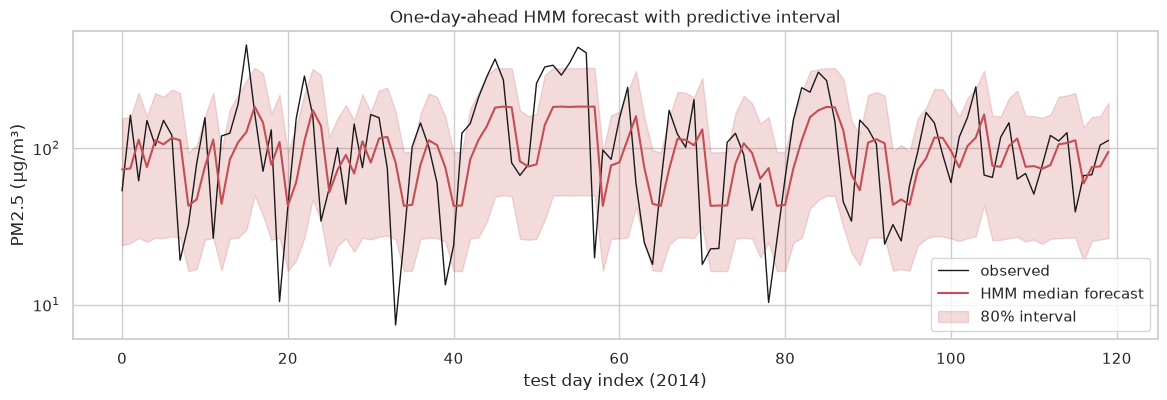

In [15]:
ytr_all = np.concatenate(train_ly); pairs = np.array([(a, b) for y in train_ly for a, b in zip(y[:-1], y[1:])])
b_ar, a_ar = np.polyfit(pairs[:, 0], pairs[:, 1], 1); s_ar = np.std(pairs[:, 1] - (a_ar + b_ar * pairs[:, 0]))
print(f"AR(1) on ln PM2.5: x_(t+1) = {a_ar:.2f} + {b_ar:.2f}·x_t, residual sd = {s_ar:.2f}   |   climatology: mean {ytr_all.mean():.2f}, sd {ytr_all.std():.2f}")

W_, X0, X1 = [], [], []
for y, gg in zip(ly_runs, runs):
    if len(y) < 2: continue
    sel = np.where(gg.index.year.values[1:] == 2014)[0]; sel = sel[sel >= 1]            # same forecast origins (≥ 2nd day of a run) for every model below
    if len(sel) == 0: continue
    alpha = g.forward_backward(y)[0]; W_.append(alpha[sel] @ g.A_); X0.append(y[sel]); X1.append(y[sel + 1])
Wn, x0, x1 = np.vstack(W_), np.concatenate(X0), np.concatenate(X1)             # predicted state weights for tomorrow, today's value, tomorrow's value

def mixture_quantile(W, mu, sd, q, grid=np.linspace(0, 8, 1600)):
    cdf = (W[:, None, :] * norm.cdf((grid[None, :, None] - mu[None, None, :]) / sd[None, None, :])).sum(-1); return grid[np.argmax(cdf >= q, axis=1)]
sd_g = np.sqrt(g.var_)
q10, q50, q90 = (mixture_quantile(Wn, g.mu_, sd_g, q) for q in (.1, .5, .9))
lpd_hmm = np.log((Wn * norm.pdf(x1[:, None], g.mu_, sd_g)).sum(1)); lpd_clim = norm.logpdf(x1, ytr_all.mean(), ytr_all.std()); lpd_ar = norm.logpdf(x1, a_ar + b_ar * x0, s_ar)
mae = lambda p: np.mean(np.abs(np.exp(p) - np.exp(x1)))
tab = pd.DataFrame({"MAE of median forecast (µg/m³)": [mae(np.full_like(x1, np.median(ytr_all))), mae(x0), mae(a_ar + b_ar * x0), mae(q50)],
                    "mean log predictive density": [lpd_clim.mean(), np.nan, lpd_ar.mean(), lpd_hmm.mean()]}, index=["climatology", "persistence (yesterday)", "AR(1) on ln PM2.5", f"Gaussian HMM (K={Kg})"]).round(3)
display(tab); print(f"80% interval coverage of the HMM mixture: {np.mean((x1 > q10) & (x1 < q90)):.1%} of {len(x1)} days (target 80%)")

idx = np.arange(0, 120)
plt.figure(figsize=(14, 4)); plt.plot(np.exp(x1[idx]), "k", lw=1, label="observed"); plt.plot(np.exp(q50[idx]), "r", label="HMM median forecast"); plt.fill_between(idx, np.exp(q10[idx]), np.exp(q90[idx]), color="r", alpha=.2, label="80% interval")
plt.yscale("log"); plt.xlabel("test day index (2014)"); plt.ylabel("PM2.5 (µg/m³)"); plt.legend(); plt.title("One-day-ahead HMM forecast with predictive interval"); plt.show()

**Reading the results.** The HMM forecast clearly improves on climatology. Against the AR(1) benchmark it has the better predictive density (it can represent the right-skewed, multi-modal distribution of tomorrow's PM2.5),
while the AR(1) point forecast has a marginally lower MAE — with only today's reading as information, a regime model and a linear autoregression extract about the same memory.
Note that the daily regimes last only about two days (expected stay ≈ 1/(1−A_ii)): at a daily resolution the Gaussian HMM largely acts as a *mixture model* of pollution levels with weak temporal structure. The hourly data below show regimes with real persistence.

#### Upgrade: Markov-switching AR on the daily series
The one-day-ahead HMM forecast above uses the *regime* only; today's value $x_t$ is ignored once the state is known. The Markov-switching AR (A2b) keeps both. We compare on the **same 2014 forecast origins**, for the continuous forecast *and* for tomorrow's air-quality class
(class probabilities = predictive mass between the class limits 35 / 75 / 150 µg/m³; the Markov chain of Problem 1 is the class baseline).

,train_ll_per_day,test_ll_per_day,BIC
K,,,
1,-1.082,-1.138,2948.354
2,-1.007,-1.068,2789.507
3,-0.990,-1.046,2800.551


BIC selects K = 2
          intercept a  persistence b     σ  median PM2.5 in the regime  P(stay)
regime 1         2.56           0.24  0.63                       29.47     0.52
regime 2         2.49           0.50  0.42                      153.00     0.73


,MAE of median forecast (µg/m³),mean log predictive density
climatology,56.532,-1.263
persistence (yesterday),52.752,NaN
AR(1) on ln PM2.5,48.783,-1.138
Gaussian HMM (K=4),49.386,-1.101
Markov-switching AR (K=2),47.999,-1.068


80% interval coverage: Gaussian HMM 77.5%   Markov-switching AR 78.6%   (365 days)


,accuracy,log_loss
climatology,0.3425,1.3602
persistence (today's class),0.4411,2.5828
Markov chain on classes,0.4438,1.2272
AR(1) on ln PM2.5,0.4329,1.2381
Gaussian HMM (K=4),0.4548,1.2324
Markov-switching AR (K=2),0.4301,1.2137


tomorrow's class, 365 forecasts in 2014   (persistence row: probability .97 on today's class, .01 elsewhere, only to give it a finite log-loss)


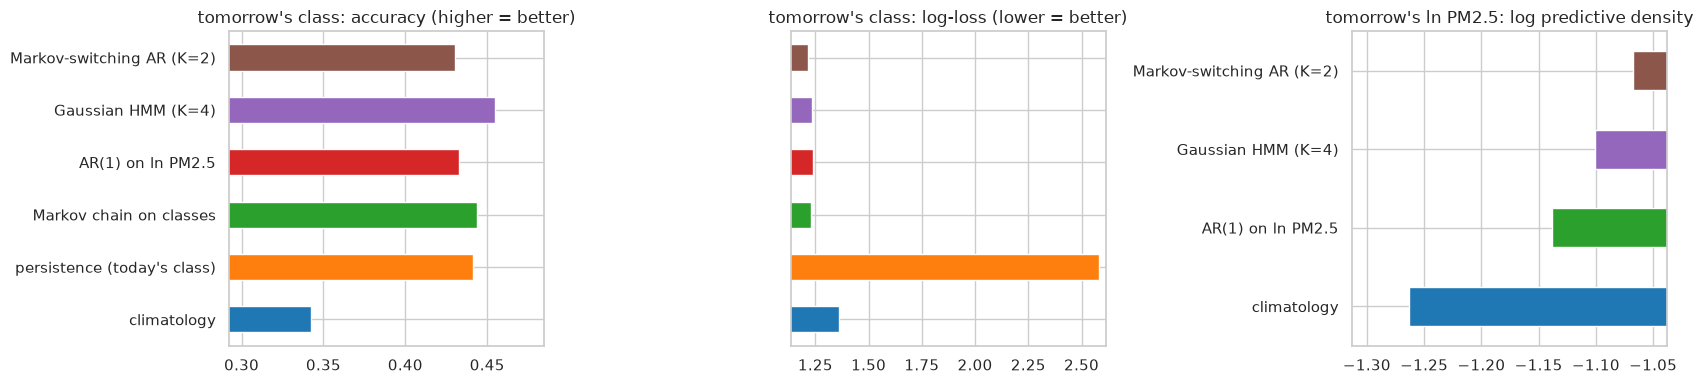

In [16]:
rows, mss = [], {}
for K in range(1, 4):
    m = MSAR(K, n_iter=150, tol=1e-4, seed=0).fit(train_ly, n_restarts=6); mss[K] = m; tl, tn = test_loglik(m, discrete=False)
    rows.append(dict(K=K, train_ll_per_day=m.loglik_ / m.n_obs_, test_ll_per_day=tl / tn, BIC=m.bic()))
selm = pd.DataFrame(rows).set_index("K"); display(selm.round(3)); Km = int(selm["BIC"].idxmin()); print("BIC selects K =", Km)
ms_ = mss[Km]; o_ = np.argsort(ms_.a_ / (1 - ms_.b_)); ms_.pi_, ms_.A_, ms_.a_, ms_.b_, ms_.var_ = ms_.pi_[o_], ms_.A_[np.ix_(o_, o_)], ms_.a_[o_], ms_.b_[o_], ms_.var_[o_]
print(pd.DataFrame({"intercept a": ms_.a_, "persistence b": ms_.b_, "σ": np.sqrt(ms_.var_), "median PM2.5 in the regime": np.exp(ms_.a_ / (1 - ms_.b_)), "P(stay)": np.diag(ms_.A_)}, index=[f"regime {k+1}" for k in range(Km)]).round(2).to_string())

cut = np.log(bj.AQI_BINS[1:-1])                                                                # class limits on the ln scale
class_p = lambda mu, sd: np.diff(np.c_[np.zeros(len(mu)), norm.cdf((cut[None] - mu[:, None]) / sd[:, None]), np.ones(len(mu))], axis=1)
def mix_q(W, mu, sd, q, grid=np.linspace(0, 8, 800)):                                           # quantile of a Gaussian mixture; mu is (n, K)
    cdf = (W[:, None, :] * norm.cdf((grid[None, :, None] - mu[:, None, :]) / sd[None, None, :])).sum(-1); return grid[np.argmax(cdf >= q, axis=1)]

Wm = []
for y, gg in zip(ly_runs, runs):
    if len(y) < 3: continue
    sel = np.array([j for j in range(1, len(y) - 1) if gg.index.year.values[j + 1] == 2014], int)
    if len(sel): Wm.append(ms_.forward_backward(y)[0][sel - 1] @ ms_.A_)                      # predicted state weights for tomorrow
Wm = np.vstack(Wm); assert len(Wm) == len(x0)
mu_m, sd_m = ms_.a_[None] + ms_.b_[None] * x0[:, None], np.sqrt(ms_.var_)
lpd_ms = np.log((Wm * norm.pdf(x1[:, None], mu_m, sd_m)).sum(1)); q50_m = mix_q(Wm, mu_m, sd_m, .5); q10_m, q90_m = mix_q(Wm, mu_m, sd_m, .1), mix_q(Wm, mu_m, sd_m, .9)
tab2 = tab.copy(); tab2.loc[f"Markov-switching AR (K={Km})"] = [mae(q50_m), lpd_ms.mean()]; display(tab2.round(3))
print(f"80% interval coverage: Gaussian HMM {np.mean((x1 > q10) & (x1 < q90)):.1%}   Markov-switching AR {np.mean((x1 > q10_m) & (x1 < q90_m)):.1%}   ({len(x1)} days)")

cls_tom, cls_today = np.digitize(x1, cut, right=True), np.digitize(x0, cut, right=True)
mixcls = lambda W, mu: sum(W[:, [k]] * class_p(mu[:, k], np.full(len(mu), sd_m_[k])) for k in range(W.shape[1]))
sd_m_ = sd_g; Pg = mixcls(Wn, np.tile(g.mu_, (len(x0), 1))); sd_m_ = sd_m; Pm = mixcls(Wm, mu_m)
P_cls = {"climatology": np.tile(freq, (len(x1), 1)), "persistence (today's class)": np.eye(4)[cls_today] * .97 + .01, "Markov chain on classes": Tm[cls_today],
         "AR(1) on ln PM2.5": class_p(a_ar + b_ar * x0, np.full(len(x0), s_ar)), f"Gaussian HMM (K={Kg})": Pg, f"Markov-switching AR (K={Km})": Pm}
ct = pd.DataFrame({k: dict(accuracy=np.mean(P.argmax(1) == cls_tom), log_loss=-np.mean(np.log(P[np.arange(len(cls_tom)), cls_tom] + 1e-12))) for k, P in P_cls.items()}).T
display(ct.round(4)); print(f"tomorrow's class, {len(cls_tom)} forecasts in 2014   (persistence row: probability .97 on today's class, .01 elsewhere, only to give it a finite log-loss)")

fig, ax = plt.subplots(1, 3, figsize=(17, 4)); cols = [PAL[i] for i in range(len(ct))]
ct["accuracy"].plot.barh(ax=ax[0], color=cols); ax[0].set(xlim=(ct["accuracy"].min() - .05, ct["accuracy"].max() + .03), title="tomorrow's class: accuracy (higher = better)")
ct["log_loss"].plot.barh(ax=ax[1], color=cols); ax[1].set(xlim=(ct["log_loss"].min() - .08, ct["log_loss"].max() + .03), title="tomorrow's class: log-loss (lower = better)"); ax[1].set_yticklabels([])
tab2["mean log predictive density"].dropna().plot.barh(ax=ax[2], color=[PAL[0], PAL[2], PAL[4], PAL[5]]); ax[2].set(xlim=(tab2["mean log predictive density"].min() - .05, tab2["mean log predictive density"].max() + .03), title="tomorrow's ln PM2.5: log predictive density")
plt.tight_layout(); plt.show()

**Reading the results (daily).** Letting the regime *and* today's value act together gives the best forecast of tomorrow's ln PM2.5: the Markov-switching AR (BIC picks K = 2: a clean/quick-changing regime and a smoggy, stickier one) has the lowest MAE (48.0 µg/m³ vs 48.8 for AR(1)) and the best log predictive density (−1.068 vs −1.138 for AR(1) and −1.101 for the plain Gaussian HMM), with a well-calibrated 80 % interval (78.6 % coverage).
For tomorrow's **class** it also has the best log-loss (1.214 vs 1.227 for the Markov chain on observed classes and 1.238 for AR(1)) — so the hidden layer *does* now add something, because the model sees how far inside a class today's value lies, which a chain on class labels cannot.
The gain is modest, though, and **accuracy** differs only by a few days out of 365 (0.430–0.455 across the sequence models; one day = 0.27 points), i.e. is within noise: with only yesterday's pollution as input there is simply not much more to learn. Large gains need new information, such as the weather (Week 2 / Week 5).

### Problem 3: zooming in — hourly ln PM2.5 (where regimes become genuinely persistent)
At an hourly resolution an air-mass episode lasts many hours (the AR(1) fit below gave φ ≈ 0.96 per hour). Fit a Gaussian HMM to the hourly series (gap-free runs, 2010–2013), choose *K* with BIC,
check the regimes against the wind (never used in the fit), and forecast **1 to 72 hours ahead** on 2014 against AR(1), persistence and climatology.

In [17]:
hr = bj.load_hourly(); yh_full = np.log(hr["pm25"].clip(lower=1)); okh = yh_full.notna(); gid = (okh != okh.shift()).cumsum()
hruns = [(r.index, r.values) for _, r in yh_full[okh].groupby(gid[okh])]                 # gap-free hourly runs
kt = [int((ix.year <= 2013).sum()) for ix, _ in hruns]
h_train = [v[:k] for (ix, v), k in zip(hruns, kt) if k >= 24]
print(f"{len(hruns)} gap-free hourly runs; training: {len(h_train)} runs, {sum(map(len, h_train))} hours (2010-13); test: {sum(len(v) - k for (ix, v), k in zip(hruns, kt) if len(v) > k)} hours (2014)")

rows, hms = [], {}
for K in range(1, 5):
    m = HMM(K, "gaussian", seed=0, n_iter=40).fit(h_train, n_restarts=2); hms[K] = m
    tl = sum(m.score(v) - (m.score(v[:k]) if k else 0.0) for (ix, v), k in zip(hruns, kt) if len(v) > k); tn = sum(len(v) - k for (ix, v), k in zip(hruns, kt) if len(v) > k)
    rows.append(dict(K=K, train_ll_per_hour=m.loglik_ / m.n_obs_, test_ll_per_hour=tl / tn, BIC=m.bic()))
selh = pd.DataFrame(rows).set_index("K"); display(selh.round(3)); Kh = int(selh["BIC"].idxmin()); print("BIC selects K =", Kh)

214 gap-free hourly runs; training: 117 runs, 32454 hours (2010-13); test: 8661 hours (2014)


,train_ll_per_hour,test_ll_per_hour,BIC
K,,,
1,-1.445,-1.485,93805.116
2,-0.964,-1.015,62651.856
3,-0.685,-0.738,44583.659
4,-0.518,-0.557,33840.539


BIC selects K = 4


                       clean  moderate  polluted    smog
median PM2.5 (µg/m³)   15.81     49.75    103.71  222.21
sd of ln PM2.5          0.48      0.29      0.23    0.33
P(stay one more hour)   0.95      0.88      0.90    0.95
expected stay (hours)  19.35      8.44     10.02   19.90


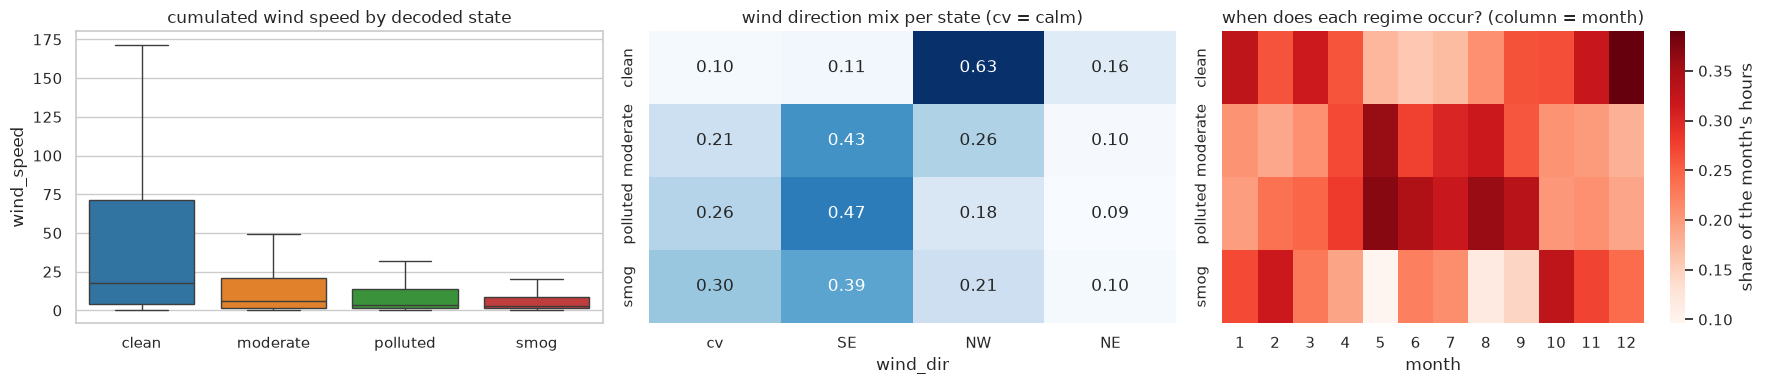

In [18]:
gh = hms[Kh]; oh = np.argsort(gh.mu_); gh.pi_, gh.A_, gh.mu_, gh.var_ = gh.pi_[oh], gh.A_[np.ix_(oh, oh)], gh.mu_[oh], gh.var_[oh]
GH = {2: ["clean", "polluted"], 3: ["clean", "moderate", "smog"], 4: ["clean", "moderate", "polluted", "smog"]}.get(Kh, [f"s{k+1}" for k in range(Kh)]); sdh = np.sqrt(gh.var_)
print(pd.DataFrame({"median PM2.5 (µg/m³)": np.exp(gh.mu_), "sd of ln PM2.5": sdh, "P(stay one more hour)": np.diag(gh.A_), "expected stay (hours)": 1 / (1 - np.diag(gh.A_))}, index=GH).round(2).T.to_string())

dec_h = [gh.viterbi(v)[0] for ix, v in hruns]
hours = pd.concat([pd.DataFrame({"state": s, "pm25": np.exp(v)}, index=ix) for (ix, v), s in zip(hruns, dec_h)]).join(hr[["wind_dir", "wind_speed", "temp", "dew"]]).sort_index()

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(data=hours, x="state", y="wind_speed", hue="state", legend=False, palette=PAL[:Kh], showfliers=False, ax=ax[0]); ax[0].set_xticks(range(Kh), GH); ax[0].set(title="cumulated wind speed by decoded state", xlabel="")
sns.heatmap(pd.crosstab(hours["state"], hours["wind_dir"], normalize="index")[["cv", "SE", "NW", "NE"]].set_axis(GH, axis=0), annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax[1]); ax[1].set_title("wind direction mix per state (cv = calm)"); ax[1].set_ylabel("")
sns.heatmap(pd.crosstab(hours["state"], hours.index.month, normalize="columns").set_axis(GH, axis=0), cmap="Reds", ax=ax[2], cbar_kws={"label": "share of the month's hours"}); ax[2].set(title="when does each regime occur? (column = month)", xlabel="month")
plt.tight_layout(); plt.show()

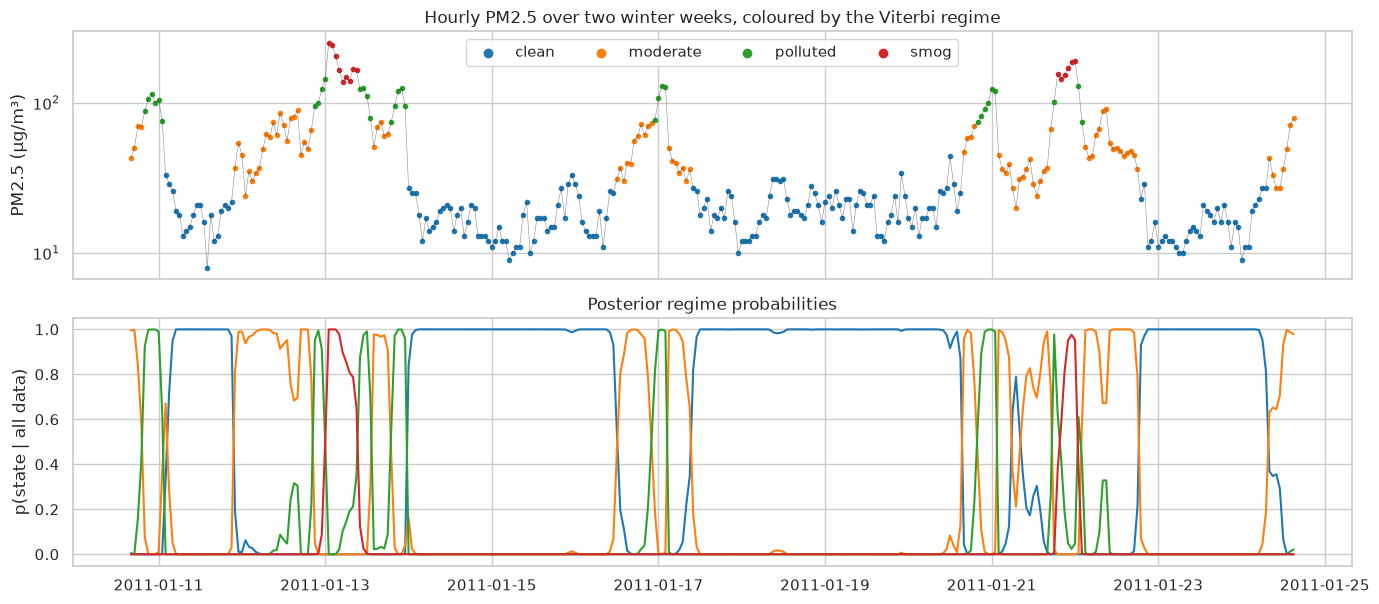

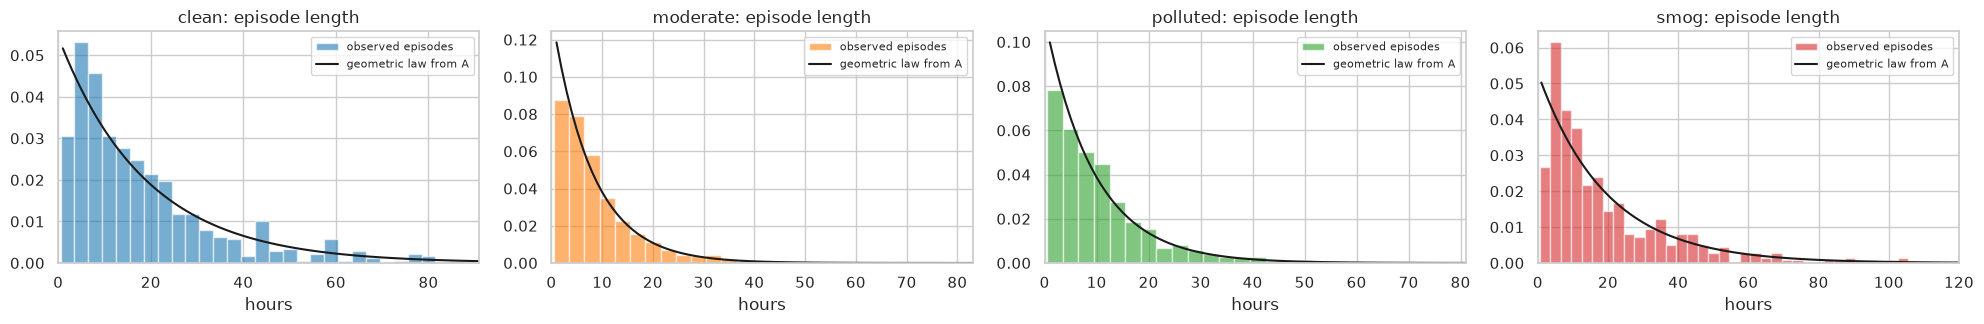

Observed episode lengths follow the geometric law implied by A reasonably well; the clean regime has fewer very short episodes and a heavier tail than the geometric law — a known limitation: a first-order HMM assumes memoryless durations.


In [19]:
# a winter fortnight: observations, decoded regimes and posteriors
cand = max(range(len(hruns)), key=lambda i: np.sum(np.isin(hruns[i][0].month, [12, 1, 2])) * (hruns[i][0].year.max() <= 2013)); ix, v = hruns[cand]
wi = np.where(np.isin(ix.month, [12, 1, 2]))[0][0]; w = slice(wi, min(wi + 336, len(v))); path_h = dec_h[cand]; post_h = gh.forward_backward(v)[2]
fig, ax = plt.subplots(2, 1, figsize=(14, 6.2), sharex=True)
for k in range(Kh): m_ = path_h[w] == k; ax[0].scatter(ix[w][m_], np.exp(v[w][m_]), s=9, color=PAL[k], label=GH[k])
ax[0].plot(ix[w], np.exp(v[w]), c="k", lw=.4, alpha=.5); ax[0].set(yscale="log", ylabel="PM2.5 (µg/m³)", title="Hourly PM2.5 over two winter weeks, coloured by the Viterbi regime"); ax[0].legend(ncol=Kh, markerscale=2)
for k in range(Kh): ax[1].plot(ix[w], post_h[w, k], c=PAL[k], label=GH[k])
ax[1].set(ylabel="p(state | all data)", title="Posterior regime probabilities"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, Kh, figsize=(5 * Kh, 3.4))
for k in range(Kh):
    lens = []
    for s in dec_h:
        cur = 0
        for z_ in s:
            if z_ == k: cur += 1
            elif cur: lens.append(cur); cur = 0
        if cur: lens.append(cur)
    mx = min(max(lens), 120); b = np.arange(1, mx + 1); stay = gh.A_[k, k]; a_ = ax[k]
    a_.hist(lens, bins=np.arange(.5, mx + 1.5, 3), density=True, alpha=.6, color=PAL[k], label="observed episodes"); a_.plot(b, stay ** (b - 1) * (1 - stay), "k-", label="geometric law from A"); a_.set(title=f"{GH[k]}: episode length", xlabel="hours", xlim=(0, mx)); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Observed episode lengths follow the geometric law implied by A reasonably well; the clean regime has fewer very short episodes and a heavier tail than the geometric law — a known limitation: a first-order HMM assumes memoryless durations.")

#### Upgrade: Markov-switching AR on the hourly series
The plain HMM above loses to AR(1) for the next few hours because, given the regime, consecutive hours are modelled as independent. The Markov-switching AR keeps the regimes **and** the autoregression: each regime is an AR(1) with its own level, persistence and noise.
We fit it to the same 2010–2013 hours and choose the number of regimes with BIC (K = 1 is the ordinary AR(1)).

In [20]:
rows, hmsar = [], {}
for K in range(1, 4):
    m = MSAR(K, n_iter=40, tol=1e-2, seed=0).fit(h_train, n_restarts=2); hmsar[K] = m
    tl = sum(m.score(v) - (m.score(v[:k]) if k else 0.0) for (ix, v), k in zip(hruns, kt) if len(v) > k); tn = sum(len(v) - max(k, 1) for (ix, v), k in zip(hruns, kt) if len(v) > k)
    rows.append(dict(K=K, train_ll_per_hour=m.loglik_ / m.n_obs_, test_ll_per_hour=tl / tn, BIC=m.bic()))
selh2 = pd.DataFrame(rows).set_index("K"); display(selh2.round(3)); Kms = int(selh2["BIC"].idxmin()); print("BIC selects K =", Kms)
mh = hmsar[Kms]; o_ = np.argsort(mh.a_ / (1 - mh.b_)); mh.pi_, mh.A_, mh.a_, mh.b_, mh.var_ = mh.pi_[o_], mh.A_[np.ix_(o_, o_)], mh.a_[o_], mh.b_[o_], mh.var_[o_]
print(pd.DataFrame({"typical PM2.5 a/(1-b) (µg/m³)": np.exp(mh.a_ / (1 - mh.b_)), "persistence b": mh.b_, "innovation sd": np.sqrt(mh.var_), "P(stay one more hour)": np.diag(mh.A_), "expected stay (hours)": 1 / (1 - np.diag(mh.A_))}, index=[f"regime {k+1}" for k in range(Kms)]).round(2).T.to_string())

,train_ll_per_hour,test_ll_per_hour,BIC
K,,,
1,-0.168,-0.154,10922.552
2,0.081,0.111,-5141.364
3,0.124,0.160,-7853.390


BIC selects K = 3
                               regime 1  regime 2  regime 3
typical PM2.5 a/(1-b) (µg/m³)     20.59     59.66    291.82
persistence b                      0.73      0.96      0.97
innovation sd                      0.57      0.23      0.09
P(stay one more hour)              0.70      0.88      0.93
expected stay (hours)              3.30      8.50     13.48


#### Forecast 1–72 hours ahead on 2014 — plain HMM vs Markov-switching AR vs AR(1)

hourly AR(1) on ln PM2.5: φ = 0.960, innovation sd = 0.286


,n,MAE_clim,MAE_persist,MAE_AR1,MAE_HMM,MAE_MSAR,CRPS_clim,CRPS_AR1,CRPS_HMM,CRPS_MSAR
h,,,,,,,,,,
1,8594,65.405,11.921,12.718,27.194,11.785,0.609,0.142,0.235,0.132
3,8534,65.377,25.341,26.840,35.405,24.864,0.608,0.263,0.323,0.254
6,8444,65.324,38.726,39.907,44.532,37.666,0.608,0.378,0.413,0.372
12,8265,65.170,53.523,52.619,53.474,51.295,0.606,0.490,0.501,0.489
24,7925,65.210,67.235,61.392,61.073,62.055,0.605,0.565,0.569,0.568
48,7324,65.329,88.173,66.100,65.858,66.531,0.614,0.620,0.616,0.621
72,6763,64.738,95.805,65.291,65.362,65.604,0.620,0.624,0.622,0.626


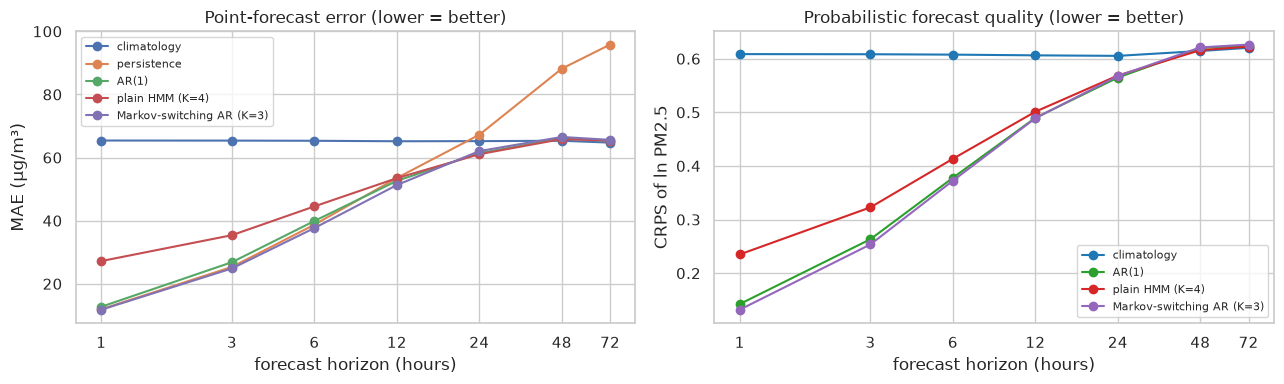

relative improvement of the Markov-switching AR over AR(1) (positive = MS-AR better):
h      1    3    6    12   24   48   72
MAE   7.3  7.4  5.6  2.5 -1.1 -0.7 -0.5
CRPS  7.4  3.7  1.4  0.1 -0.5 -0.2 -0.3


In [21]:
yh_tr = np.concatenate(h_train); pr = np.array([(a, b) for y in h_train for a, b in zip(y[:-1], y[1:])]); b1, a1 = np.polyfit(pr[:, 0], pr[:, 1], 1); s1 = np.std(pr[:, 1] - a1 - b1 * pr[:, 0]); mu_ar = a1 / (1 - b1)
print(f"hourly AR(1) on ln PM2.5: φ = {b1:.3f}, innovation sd = {s1:.3f}")
def mixq(W, mu, sd, q, grid=np.linspace(0, 8, 800)):
    cdf = (W[:, None, :] * norm.cdf((grid[None, :, None] - mu[None, None, :]) / sd[None, None, :])).sum(-1); return grid[np.argmax(cdf >= q, axis=1)]
def crps_samples(S, x):                                           # continuous ranked probability score of a sample forecast (lower = better)
    N = S.shape[1]; Ss = np.sort(S, 1); i = np.arange(1, N + 1); return np.abs(S - x[:, None]).mean(1) - ((2 * i - N - 1) * Ss).sum(1) / N ** 2
def crps_gauss(mu, sd, x): z = (x - mu) / sd; return sd * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
def mix_samples(W, mu, sd, N=300, seed=0):
    r = np.random.default_rng(seed); z = (r.random((len(W), N, 1)) > W.cumsum(1)[:, None, :]).sum(2).clip(max=len(mu) - 1); return r.normal(mu[z], sd[z])

HZ = [1, 3, 6, 12, 24, 48, 72]; out = []; hr3 = [(ix, v) for ix, v in hruns if len(v) > 2]
al_plain = [gh.forward_backward(v)[0] for ix, v in hr3]; al_ms = [mh.forward_backward(v)[0] for ix, v in hr3]       # al_ms[j] filters up to x[j+1]
for hh in HZ:
    W_, A_, X0, XT = [], [], [], []
    for (ix, v), ap, am in zip(hr3, al_plain, al_ms):
        sel = np.arange(1, len(v) - hh); sel = sel[ix.year.values[sel + hh] == 2014]                                  # origins t ≥ 1 whose target is in 2014
        if len(sel) == 0: continue
        W_.append(ap[sel] @ np.linalg.matrix_power(gh.A_, hh)); A_.append(am[sel - 1]); X0.append(v[sel]); XT.append(v[sel + hh])
    Wn_, An_, x0_, xt_ = np.vstack(W_), np.vstack(A_), np.concatenate(X0), np.concatenate(XT)
    m_ar = mu_ar + b1 ** hh * (x0_ - mu_ar); s_ar_h = s1 * np.sqrt((1 - b1 ** (2 * hh)) / (1 - b1 ** 2))
    S_ms = mh.forecast_samples(An_, x0_, hh, 300, seed=hh); S_hmm = mix_samples(Wn_, gh.mu_, sdh, seed=hh)
    mae_ = lambda p: np.mean(np.abs(np.exp(p) - np.exp(xt_)))
    out.append(dict(h=hh, n=len(xt_), MAE_clim=mae_(np.full_like(xt_, np.median(yh_tr))), MAE_persist=mae_(x0_), MAE_AR1=mae_(m_ar), MAE_HMM=mae_(mixq(Wn_, gh.mu_, sdh, .5)), MAE_MSAR=mae_(np.median(S_ms, 1)),
                    CRPS_clim=crps_gauss(yh_tr.mean(), yh_tr.std(), xt_).mean(), CRPS_AR1=crps_gauss(m_ar, s_ar_h, xt_).mean(), CRPS_HMM=crps_samples(S_hmm, xt_).mean(), CRPS_MSAR=crps_samples(S_ms, xt_).mean()))
fc = pd.DataFrame(out).set_index("h"); display(fc.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 4)); LAB = [("clim", "climatology"), ("persist", "persistence"), ("AR1", "AR(1)"), ("HMM", f"plain HMM (K={Kh})"), ("MSAR", f"Markov-switching AR (K={Kms})")]
for c_, l_ in LAB: ax[0].plot(fc.index, fc[f"MAE_{c_}"], "o-", label=l_)
ax[0].set(xlabel="forecast horizon (hours)", ylabel="MAE (µg/m³)", title="Point-forecast error (lower = better)", xscale="log"); ax[0].legend(fontsize=8); ax[0].set_xticks(HZ, HZ)
for c_, l_ in [x for x in LAB if x[0] != "persist"]: ax[1].plot(fc.index, fc[f"CRPS_{c_}"], "o-", label=l_, color=PAL[[x[0] for x in LAB].index(c_)])
ax[1].set(xlabel="forecast horizon (hours)", ylabel="CRPS of ln PM2.5", title="Probabilistic forecast quality (lower = better)", xscale="log"); ax[1].legend(fontsize=8); ax[1].set_xticks(HZ, HZ)
plt.tight_layout(); plt.show()
rel = pd.DataFrame({"MAE": 1 - fc["MAE_MSAR"] / fc["MAE_AR1"], "CRPS": 1 - fc["CRPS_MSAR"] / fc["CRPS_AR1"]}); print("relative improvement of the Markov-switching AR over AR(1) (positive = MS-AR better):"); print((100 * rel).round(1).T.to_string())

**Reading the results.** The decoded regimes of the plain HMM are physically meaningful: the clean regime coincides with strong north-westerly winds, the smog regime with weak wind and calm hours, and smog is over-represented in the cold months (heating season) — all inferred without using the weather.
As a **short-term forecaster**, though, the plain 4-state HMM is clearly worse than persistence/AR(1) (MAE 27 vs 13 µg/m³ at 1 h), because given the state the hourly values are modelled as independent and cannot follow the smooth drift *inside* a regime.
The **Markov-switching AR** fixes exactly that weakness. Its three regimes differ in level (typical PM2.5 ≈ 21, 60 and 290 µg/m³), persistence (0.73 → 0.97) and noise (the smog regime is smooth, the clean regime jumpy), and the model beats the AR(1) baseline for the first hours: about **7 % lower MAE and CRPS at 1 h**, 4–7 % at 3 h, 1–6 % at 6 h and ≈ 2 % in MAE at 12 h, and it also beats the 1-hour persistence forecast (11.8 vs 11.9 µg/m³ MAE; that margin is tiny).
Beyond about 12–24 hours all methods converge (differences ≤ 1 %, with AR(1) fractionally ahead), since the current level no longer matters and everything relaxes to climatology.
So the lesson is not that HMMs cannot forecast: a plain HMM is the wrong emission model for a smooth series, while the regime-switching *autoregression* gives a measurable gain at short horizons and keeps the interpretable regimes and multi-modal uncertainty.

## Linear dynamical systems (Kalman filter)
The continuous-latent-state analogue of the HMM: $\mathbf z_t=F\mathbf z_{t-1}+\mathbf w_t$ ($\mathbf w\sim\mathcal N(0,Q)$), $\mathbf x_t=H\mathbf z_t+\mathbf v_t$ ($\mathbf v\sim\mathcal N(0,R)$).
Inference is again forward–backward: the **Kalman filter** (forward, gives $p(\mathbf z_t|x_{1:t})$) and the **Rauch–Tung–Striebel smoother** (backward, gives $p(\mathbf z_t|x_{1:T})$); everything stays Gaussian.
The implementation below also **skips the update when a measurement is missing** (NaN) and returns the log-likelihood, so that parameters can be fitted by maximum likelihood.
First a tracking example (synthetic; state = position and velocity), then a Beijing application: filling gaps in the hourly PM2.5 record.

position RMSE: raw measurements 2.233   Kalman filter 1.085   RTS smoother 0.830


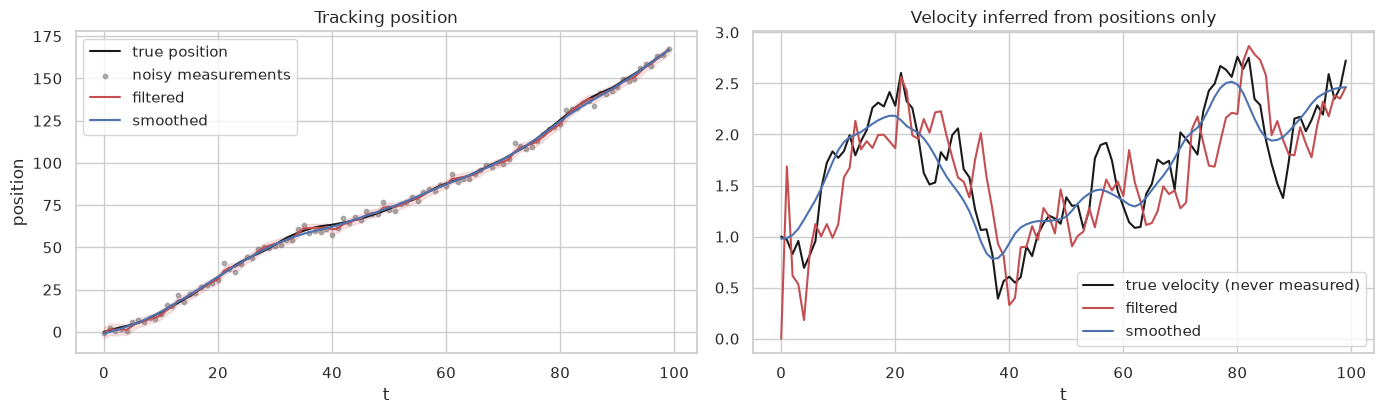

In [22]:
def kalman(x, F, H, Q, R, m0, P0, U=None):
    """Kalman filter + RTS smoother. x: (T, d_obs) with NaN rows = missing; optional known inputs U: (T, d) added to the state prediction, z_t = F z_(t-1) + U_t + w_t.
    Returns filtered/smoothed means & covariances and log-likelihood."""
    T, d = len(x), len(m0); mf, Pf, mp, Pp = np.zeros((T, d)), np.zeros((T, d, d)), np.zeros((T, d)), np.zeros((T, d, d)); m, P, ll = m0, P0, 0.0
    for t in range(T):
        mp[t], Pp[t] = (F @ m + (0 if U is None else U[t]), F @ P @ F.T + Q) if t > 0 else (m0, P0)                    # predict
        m, P = mp[t], Pp[t]
        if not np.any(np.isnan(x[t])):                                                    # update (skipped when the measurement is missing)
            S = H @ Pp[t] @ H.T + R; K = Pp[t] @ H.T @ np.linalg.inv(S); e = x[t] - H @ mp[t]
            m = mp[t] + K @ e; P = (np.eye(d) - K @ H) @ Pp[t]; ll += -0.5 * (np.linalg.slogdet(2 * np.pi * S)[1] + e @ np.linalg.solve(S, e))
        mf[t], Pf[t] = m, P
    ms, Ps = mf.copy(), Pf.copy()                                                          # RTS smoother
    for t in range(T - 2, -1, -1):
        J = Pf[t] @ F.T @ np.linalg.inv(Pp[t + 1]); ms[t] = mf[t] + J @ (ms[t + 1] - mp[t + 1]); Ps[t] = Pf[t] + J @ (Ps[t + 1] - Pp[t + 1]) @ J.T
    return mf, Pf, ms, Ps, ll

dt = 1.0; F = np.array([[1, dt], [0, 1]]); H = np.array([[1.0, 0.0]]); Q = 0.05 * np.array([[dt ** 3 / 3, dt ** 2 / 2], [dt ** 2 / 2, dt]]); R = np.array([[4.0]])
rng = np.random.default_rng(0); T = 100; z = np.zeros((T, 2)); z[0] = [0, 1]
for t in range(1, T): z[t] = F @ z[t - 1] + rng.multivariate_normal([0, 0], Q)
xobs = z[:, :1] + rng.normal(0, np.sqrt(R[0, 0]), (T, 1))
mf, Pf, ms, Ps, ll = kalman(xobs, F, H, Q, R, np.array([0.0, 0.0]), np.eye(2) * 10)

rm = lambda e: np.sqrt(np.mean(e ** 2))
print(f"position RMSE: raw measurements {rm(xobs[:, 0] - z[:, 0]):.3f}   Kalman filter {rm(mf[:, 0] - z[:, 0]):.3f}   RTS smoother {rm(ms[:, 0] - z[:, 0]):.3f}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
ax[0].plot(z[:, 0], "k", label="true position"); ax[0].scatter(range(T), xobs[:, 0], s=10, c="gray", alpha=.6, label="noisy measurements")
ax[0].plot(mf[:, 0], "r", label="filtered"); ax[0].plot(ms[:, 0], "b", label="smoothed"); sd = np.sqrt(Pf[:, 0, 0]); ax[0].fill_between(range(T), mf[:, 0] - 2 * sd, mf[:, 0] + 2 * sd, color="r", alpha=.15)
ax[0].legend(); ax[0].set(xlabel="t", ylabel="position", title="Tracking position")
ax[1].plot(z[:, 1], "k", label="true velocity (never measured)"); ax[1].plot(mf[:, 1], "r", label="filtered"); ax[1].plot(ms[:, 1], "b", label="smoothed"); ax[1].legend(); ax[1].set(xlabel="t", title="Velocity inferred from positions only")
plt.tight_layout(); plt.show()

**Beijing application — filling gaps in the hourly PM2.5 record.** The monitor has 2,067 missing hours (gaps up to 155 hours), whereas the weather record is complete. We compare three ways to fill a gap and score each on **hidden** stretches of gap-free 2014 data (all parameters come from 2010–2013):

1. **linear interpolation** between the two ends of the gap — the usual default;
2. **Kalman / RTS smoother with a latent AR(1)** for ln PM2.5: $z_t-\mu=\phi(z_{t-1}-\mu)+w_t$, observed with noise (parameters by maximum likelihood);
3. the same state-space model **with weather inputs** (an ARX state equation): $z_t=\phi z_{t-1}+c+\boldsymbol\beta^\top\mathbf u_t+w_t$, where $\mathbf u_t$ holds dew point, temperature, pressure, log wind speed, wind-direction dummies and annual/daily cycles **at hour $t$**.
The inputs enter the prediction step (the `U` argument of our `kalman`), so inside a gap the smoother does not only pull the state towards the two ends but also follows what the weather says happened in between. No pollution value from inside the gap is ever used.

gap-free stretches ≥ 300 h: 38 in 2010-13 (to fit the models), 11 in 2014 (6228 hours, to evaluate)


(2) AR(1) state space:  μ = 4.23 (≈ 69 µg/m³), φ = 0.950, process var = 0.0727, measurement var = 1.4e-13
(3) AR(1) + weather:    φ = 0.894, process var = 0.0765;  strongest weather effects (per s.d.): dew +0.11, temp -0.11, wind_NW -0.04, log_wind -0.04


imputation RMSE on ln PM2.5 (lower = better), 200 hidden gaps per length:


,interpolation,Kalman AR(1),Kalman AR(1) + weather,weather model wins in
gap (hours),,,,
1,0.175,0.175,0.178,0.420
3,0.279,0.279,0.277,0.485
6,0.338,0.339,0.326,0.470
12,0.492,0.494,0.441,0.575
24,0.660,0.644,0.526,0.635
48,0.863,0.825,0.620,0.650


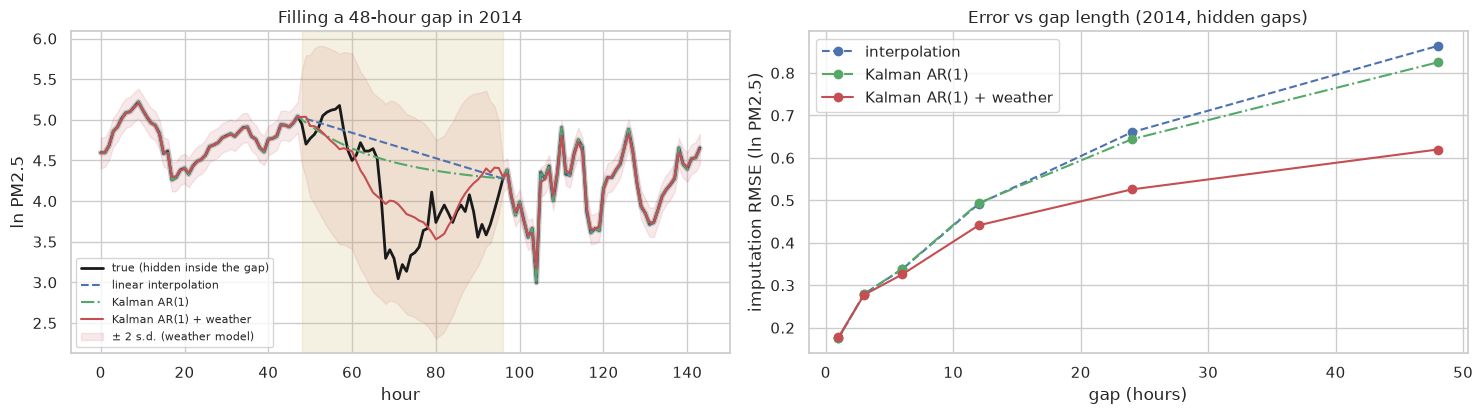

In [23]:
hr = bj.load_hourly(); yh = np.log(hr["pm25"].clip(lower=1)); okh = yh.notna(); gid2 = (okh != okh.shift()).cumsum()
Wx = pd.DataFrame({"dew": hr.dew, "temp": hr.temp, "pres": hr.pres, "log_wind": np.log1p(hr.wind_speed)})
for w_ in ["NE", "NW", "SE"]: Wx[f"wind_{w_}"] = (hr.wind_dir == w_).astype(float)
Wx["s_sin"], Wx["s_cos"] = np.sin(2 * np.pi * hr.index.dayofyear / 365.25), np.cos(2 * np.pi * hr.index.dayofyear / 365.25)
Wx["h_sin"], Wx["h_cos"] = np.sin(2 * np.pi * hr.index.hour / 24), np.cos(2 * np.pi * hr.index.hour / 24)
gf = [r for _, r in yh[okh].groupby(gid2[okh]) if len(r) >= 300]                       # gap-free stretches of at least 300 hours
g_tr = [r for r in gf if r.index[-1].year <= 2013]; g_te = [r for r in gf if r.index[0].year >= 2014]
print(f"gap-free stretches ≥ 300 h: {len(g_tr)} in 2010-13 (to fit the models), {len(g_te)} in 2014 ({sum(map(len, g_te))} hours, to evaluate)")

# (2) latent AR(1) + measurement noise: maximum likelihood with the Kalman filter (first 300 h of 6 training stretches)
def nll(p):
    mu, phi, q, r = p[0], np.tanh(p[1]), np.exp(p[2]), np.exp(p[3])
    return -sum(kalman((r_.values[:300] - mu)[:, None], np.array([[phi]]), np.eye(1), np.array([[q]]), np.array([[r]]), np.zeros(1), np.array([[q / (1 - phi ** 2)]]))[-1] for r_ in g_tr[:6])
fit = optimize.minimize(nll, [yh.mean(), 2.0, np.log(.05), np.log(.02)], method="Nelder-Mead", options=dict(maxiter=250))
mu1, phi1, q1, r1 = fit.x[0], np.tanh(fit.x[1]), np.exp(fit.x[2]), np.exp(fit.x[3]); print(f"(2) AR(1) state space:  μ = {mu1:.2f} (≈ {np.exp(mu1):.0f} µg/m³), φ = {phi1:.3f}, process var = {q1:.4f}, measurement var = {r1:.2g}")

# (3) AR(1) with weather inputs: with negligible measurement noise the maximum-likelihood coefficients are the least-squares fit of ln x_t on ln x_(t-1) and the weather at hour t
Z = np.vstack([np.c_[r_.values[:-1], Wx.loc[r_.index[1:]].values] for r_ in g_tr]); yz = np.concatenate([r_.values[1:] for r_ in g_tr])
wm, ws = Z[:, 1:].mean(0), Z[:, 1:].std(0); D = np.c_[np.ones(len(Z)), Z[:, 0], (Z[:, 1:] - wm) / ws]; coef = np.linalg.lstsq(D, yz, rcond=None)[0]
phi2, q2, r2 = coef[1], np.var(yz - D @ coef), 1e-2                                       # r2: a small fixed sensor noise (≈ 10 % relative error)
print(f"(3) AR(1) + weather:    φ = {phi2:.3f}, process var = {q2:.4f};  strongest weather effects (per s.d.): " + ", ".join(f"{n_} {c_:+.2f}" for n_, c_ in sorted(zip(Wx.columns, coef[2:]), key=lambda t: -abs(t[1]))[:4]))
Id = np.eye(1)

def fill(xm, idx, method):
    """Fill NaNs of xm (ln PM2.5 on hourly index idx); returns the filled/smoothed series and, for the state-space models, its variance."""
    if method == "interpolation": return pd.Series(xm).interpolate().values, None
    if method == "Kalman AR(1)":
        _, _, ms_, Ps_, _ = kalman((xm - mu1)[:, None], np.array([[phi1]]), Id, np.array([[q1]]), np.array([[r1 + 1e-9]]), np.zeros(1), np.array([[q1 / (1 - phi1 ** 2)]])); return ms_[:, 0] + mu1, Ps_[:, 0, 0]
    u = (coef[0] + ((Wx.loc[idx].values - wm) / ws) @ coef[2:])[:, None]
    _, _, ms_, Ps_, _ = kalman(xm[:, None], np.array([[phi2]]), Id, np.array([[q2]]), np.array([[r2]]), u[0] / (1 - phi2), np.array([[q2 / (1 - phi2 ** 2)]]), U=u); return ms_[:, 0], Ps_[:, 0, 0]

METHODS = ["interpolation", "Kalman AR(1)", "Kalman AR(1) + weather"]; rng = np.random.default_rng(0); rows = []
for L in [1, 3, 6, 12, 24, 48]:
    err = {k: [] for k in METHODS}
    for _ in range(200):                                                                    # hide L consecutive hours inside a random 2014 stretch (48 h of context on each side)
        run = g_te[rng.integers(len(g_te))]; s0 = rng.integers(48, len(run) - 48 - L); seg = run.iloc[s0 - 48: s0 + L + 48]; xv = seg.values; xm = xv.copy(); xm[48:48 + L] = np.nan
        for k in METHODS: err[k].append(np.mean((fill(xm, seg.index, k)[0][48:48 + L] - xv[48:48 + L]) ** 2))
    rows.append({"gap (hours)": L, **{k: np.sqrt(np.mean(err[k])) for k in METHODS}, "weather model wins in": np.mean(np.array(err[METHODS[2]]) < np.array(err[METHODS[0]]))})
imp = pd.DataFrame(rows).set_index("gap (hours)"); print("imputation RMSE on ln PM2.5 (lower = better), 200 hidden gaps per length:"); display(imp.round(3))

# one 48-hour gap in 2014
run = g_te[int(np.argmax([len(r_) for r_ in g_te]))]; s0 = 250; seg = run.iloc[s0 - 48: s0 + 96]; xv = seg.values; xm = xv.copy(); xm[48:96] = np.nan
fills = {k: fill(xm, seg.index, k) for k in METHODS}
fig, ax = plt.subplots(1, 2, figsize=(15, 4.3)); t_ = np.arange(len(xv))
ax[0].plot(t_, xv, "k", lw=2, label="true (hidden inside the gap)"); ax[0].plot(t_[:48], xv[:48], c="gray", lw=4, alpha=.4); ax[0].plot(t_[96:], xv[96:], c="gray", lw=4, alpha=.4)
ax[0].plot(t_, fills["interpolation"][0], "b--", label="linear interpolation"); ax[0].plot(t_, fills["Kalman AR(1)"][0], "g-.", label="Kalman AR(1)"); ax[0].plot(t_, fills[METHODS[2]][0], "r", label="Kalman AR(1) + weather")
sdw = np.sqrt(fills[METHODS[2]][1]); ax[0].fill_between(t_, fills[METHODS[2]][0] - 2 * sdw, fills[METHODS[2]][0] + 2 * sdw, color="r", alpha=.12, label="± 2 s.d. (weather model)")
ax[0].axvspan(48, 96, color="y", alpha=.2); ax[0].set(xlabel="hour", ylabel="ln PM2.5", title="Filling a 48-hour gap in 2014"); ax[0].legend(fontsize=8)
imp[METHODS].plot(marker="o", ax=ax[1], color=["b", "g", "r"], style=["--", "-.", "-"]); ax[1].set(ylabel="imputation RMSE (ln PM2.5)", title="Error vs gap length (2014, hidden gaps)")
plt.tight_layout(); plt.show()

**Reading the results.** A latent AR(1) alone is *no better* than linear interpolation (identical up to ~12 hours, only 2–4 % better at 24–48 h): both use only the two ends of the gap, and for such a persistent series the best guess from the ends is nearly a straight line.
Adding the weather as known inputs changes that. For short gaps (≤ 3 h) the endpoints dominate and all three methods agree, but for long gaps the weather tells the smoother what happened *inside* the gap and the error drops sharply: about 10 % at 12 h, 20 % at 24 h and 28 % at 48 h relative to interpolation (RMSE 0.53 vs 0.66 and 0.62 vs 0.86 on the ln scale), winning in 64–65 % of the individual long gaps (it wins in fewer than half of the very short ones, where the difference is negligible).
The smoother also supplies a ± 2 s.d. band for every imputed hour, which interpolation cannot. The fitted effects are plausible: higher dew point (humid, stagnant air) raises and warmer temperature lowers PM2.5, as does north-westerly or strong wind.

## Summary
* Markov chains: ML transition estimates and stationary distributions, estimated on real daily air-quality classes.
* Implemented the **HMM from scratch**: scaled forward–backward (verified against brute-force enumeration), **Baum–Welch** (likelihood monotonically increases), **Viterbi** decoding, and h-step prediction.
* Learned a discrete HMM on Beijing's daily air-quality classes, found hidden pollution regimes (BIC selects the number), validated them against weather the model never saw (smog regime ↔ calm, weak wind), and forecast 1–10 days ahead against climatology, Markov-chain and persistence baselines on the held-out year 2014.
* Gaussian-emission HMM on daily ln PM2.5 (regime detection, one-step predictive mixture vs climatology and AR(1)) and on the hourly series (persistent regimes validated against wind, 1–72 h forecasts).
* **Markov-switching AR** (an HMM whose emission depends on the previous observation) implemented as a subclass and validated by parameter recovery: it fixes the plain HMM's weakness for short-term forecasts — about 7 % lower MAE/CRPS than AR(1) at 1 h on the 2014 hold-out, converging to AR(1) beyond ~12 h — and gives the best daily predictive density; for tomorrow's air-quality class it improves log-loss slightly over the Markov chain, while accuracy is within noise.
* Linear dynamical systems: Kalman filter and RTS smoother with missing-data handling, known inputs and ML parameter fitting; tracking, and gap-filling of the hourly PM2.5 record — with weather inputs the smoother cuts the error of 24–48 h gaps by 20–28 % relative to linear interpolation (a plain latent AR(1) is no better than interpolation).